# Hotel Bar Inventory Forecasting & Par Level Recommendation System

## AI/ML Internship Assignment — Krystal Ball

**Prepared by:** Rishabh Kushwaha

**Project Type:** AI/ML — Inventory Demand Forecasting

**Objective:**  
Develop a data-driven system for hotel bar demand forecasting,
dynamic par level recommendation, safety stock calculation,
and inventory policy backtesting.

## 1. Business Problem

Hotel bars need to maintain sufficient inventory to meet customer
demand while avoiding excessive stock holding.

If inventory is too low, the bar may experience stockouts and
potential lost sales.

If inventory is too high, it can result in unnecessary inventory
holding and inefficient working capital utilization.

The objective of this project is to use historical consumption
data to forecast future demand and recommend dynamic inventory
par levels for different bar and brand combinations.

## 2. Project Objectives

The project will:

1. Clean and validate transaction-level inventory data.
2. Aggregate consumption into daily time series.
3. Analyze consumption patterns across bars and brands.
4. Identify high-, medium-, and low-velocity products.
5. Analyze day-of-week and seasonal demand patterns.
6. Identify historical stockout situations.
7. Develop demand forecasting models.
8. Compare forecasting models using MAE and WAPE.
9. Calculate safety stock based on demand variability.
10. Recommend dynamic inventory par levels.
11. Simulate inventory replenishment policies.
12. Backtest the inventory policy using historical demand.
13. Evaluate stockouts, inventory levels, and potential business impact.

## 3. Import Libraries

In [116]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 4. Load Dataset

In [3]:
# Dataset path
file_path = "../data/raw/bar_inventory_data.csv"

# Load dataset
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 6,575
Columns: 8


In [4]:
df.head()

,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
0,1/1/2023 19:35,Smith's Bar,Rum,Captain Morgan,2555.04,1824.84,0.0,4379.88
1,1/1/2023 10:07,Smith's Bar,Wine,Yellow Tail,1344.37,0.00,0.0,1344.37
2,1/1/2023 11:26,Johnson's Bar,Vodka,Grey Goose,1034.28,0.00,0.0,1034.28
3,1/1/2023 13:53,Johnson's Bar,Beer,Coors,2194.53,0.00,0.0,2194.53
4,1/1/2023 22:28,Johnson's Bar,Wine,Yellow Tail,1020.90,0.00,0.0,1020.90


In [5]:
df.columns

Index(['Date Time Served', 'Bar Name', 'Alcohol Type', 'Brand Name',
       'Opening Balance (ml)', 'Purchase (ml)', 'Consumed (ml)',
       'Closing Balance (ml)'],
      dtype='str')

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 6575
Number of columns: 8


In [7]:
df.dtypes

Date Time Served            str
Bar Name                    str
Alcohol Type                str
Brand Name                  str
Opening Balance (ml)    float64
Purchase (ml)           float64
Consumed (ml)           float64
Closing Balance (ml)    float64
dtype: object

In [8]:
df.head()

,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
0,1/1/2023 19:35,Smith's Bar,Rum,Captain Morgan,2555.04,1824.84,0.0,4379.88
1,1/1/2023 10:07,Smith's Bar,Wine,Yellow Tail,1344.37,0.00,0.0,1344.37
2,1/1/2023 11:26,Johnson's Bar,Vodka,Grey Goose,1034.28,0.00,0.0,1034.28
3,1/1/2023 13:53,Johnson's Bar,Beer,Coors,2194.53,0.00,0.0,2194.53
4,1/1/2023 22:28,Johnson's Bar,Wine,Yellow Tail,1020.90,0.00,0.0,1020.90


In [9]:
df.tail()

,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
6570,1/1/2024 21:03,Anderson's Bar,Beer,Coors,2.467080e+03,0.00,321.06,2146.02
6571,1/1/2024 21:15,Anderson's Bar,Rum,Malibu,8.530000e-14,1743.64,175.05,1568.59
6572,1/1/2024 18:34,Anderson's Bar,Whiskey,Jack Daniels,4.192660e+03,0.00,197.60,3995.06
6573,1/1/2024 22:46,Thomas's Bar,Vodka,Absolut,2.424950e+03,0.00,128.52,2296.43
6574,1/1/2024 21:26,Thomas's Bar,Rum,Bacardi,1.778360e+03,1195.45,572.60,2401.21


In [10]:
df.sample(5, random_state=42)

,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
611,2/1/2023 17:55,Thomas's Bar,Beer,Heineken,3408.67,0.00,161.26,3247.41
4442,9/3/2023 20:44,Brown's Bar,Rum,Malibu,915.74,1128.74,417.71,1626.77
1419,3/18/2023 16:36,Anderson's Bar,Wine,Sutter Home,6471.43,0.00,571.38,5900.05
5583,11/7/2023 12:40,Johnson's Bar,Rum,Bacardi,1882.43,0.00,524.11,1358.32
3094,6/19/2023 12:29,Brown's Bar,Rum,Bacardi,4325.25,0.00,308.83,4016.42


In [11]:
df.describe()

,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
count,6575.000000,6575.000000,6575.000000,6575.000000
mean,2468.397180,315.841757,299.419264,2484.811748
std,2284.552895,582.120264,191.903874,2302.363298
min,0.000000,0.000000,0.000000,0.000000
25%,619.135000,0.000000,156.640000,611.000000
50%,1848.440000,0.000000,300.390000,1849.840000
75%,3853.020000,526.345000,450.870000,3906.050000
max,11862.520000,1999.840000,1180.580000,11862.520000


In [12]:
print("Total Bars:", df["Bar Name"].nunique())

print("\nBars:")
print(df["Bar Name"].unique())

Total Bars: 6

Bars:
<StringArray>
[   'Smith's Bar',  'Johnson's Bar',    'Brown's Bar',   'Taylor's Bar',
 'Anderson's Bar',   'Thomas's Bar']
Length: 6, dtype: str


In [13]:
df["Bar Name"].value_counts()

Bar Name
Johnson's Bar     1106
Anderson's Bar    1102
Thomas's Bar      1101
Brown's Bar       1100
Taylor's Bar      1088
Smith's Bar       1078
Name: count, dtype: int64

In [14]:
print("Total Alcohol Types:", df["Alcohol Type"].nunique())

print("\nAlcohol Types:")
print(df["Alcohol Type"].unique())

Total Alcohol Types: 5

Alcohol Types:
<StringArray>
['Rum', 'Wine', 'Vodka', 'Beer', 'Whiskey']
Length: 5, dtype: str


In [15]:
df["Alcohol Type"].value_counts()

Alcohol Type
Vodka      1331
Wine       1316
Whiskey    1316
Rum        1310
Beer       1302
Name: count, dtype: int64

In [16]:
print("Total Brands:", df["Brand Name"].nunique())

print("\nBrands:")
print(df["Brand Name"].unique())

Total Brands: 16

Brands:
<StringArray>
['Captain Morgan',    'Yellow Tail',     'Grey Goose',          'Coors',
       'Jim Beam',        'Absolut',   'Jack Daniels',    'Sutter Home',
         'Miller',        'Bacardi',         'Malibu',        'Jameson',
       'Smirnoff',      'Budweiser',       'Heineken',       'Barefoot']
Length: 16, dtype: str


In [17]:
df["Brand Name"].value_counts()

Brand Name
Yellow Tail       479
Captain Morgan    471
Grey Goose        465
Jim Beam          455
Smirnoff          434
Jack Daniels      433
Absolut           432
Jameson           428
Malibu            425
Barefoot          424
Bacardi           414
Sutter Home       413
Miller            363
Coors             325
Heineken          314
Budweiser         300
Name: count, dtype: int64

In [18]:
brand_alcohol_check = (
    df.groupby("Brand Name")["Alcohol Type"]
    .nunique()
    .sort_values(ascending=False)
)

brand_alcohol_check

Brand Name
Absolut           1
Bacardi           1
Barefoot          1
Budweiser         1
Captain Morgan    1
Coors             1
Grey Goose        1
Heineken          1
Jack Daniels      1
Jameson           1
Jim Beam          1
Malibu            1
Miller            1
Smirnoff          1
Sutter Home       1
Yellow Tail       1
Name: Alcohol Type, dtype: int64

In [19]:
df["Date Time Served"].dtype

<StringDtype(storage='python', na_value=nan)>

In [20]:
df["Date Time Served"] = pd.to_datetime(
    df["Date Time Served"],
    errors="coerce"
)

In [21]:
print(df["Date Time Served"].dtype)

datetime64[us]


In [22]:
date_errors = df["Date Time Served"].isna().sum()

print("Invalid date values:", date_errors)

Invalid date values: 0


In [23]:
print("Start Date:", df["Date Time Served"].min())
print("End Date:", df["Date Time Served"].max())

Start Date: 2023-01-01 10:07:00
End Date: 2024-01-01 22:46:00


In [24]:
total_consumption = df["Consumed (ml)"].sum()

print(f"Total Consumption: {total_consumption:,.2f} ml")

Total Consumption: 1,968,681.66 ml


In [25]:
total_purchase = df["Purchase (ml)"].sum()

print(f"Total Purchase: {total_purchase:,.2f} ml")

Total Purchase: 2,076,659.55 ml


In [26]:
zero_consumption = (df["Consumed (ml)"] == 0).sum()

print("Zero Consumption Records:", zero_consumption)
print(
    f"Percentage: {zero_consumption / len(df) * 100:.2f}%"
)

Zero Consumption Records: 910
Percentage: 13.84%


In [27]:
zero_closing = (df["Closing Balance (ml)"] == 0).sum()

print("Records with zero closing balance:", zero_closing)

Records with zero closing balance: 416


## 5. Data Quality Checks

Before performing forecasting and inventory analysis, the dataset is
validated for missing values, duplicate records, invalid dates,
negative inventory quantities, and inventory conservation consistency.

### 5.1 Missing Value Analysis

In [119]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (
        missing_values / len(df) * 100
    ).round(2)
})

missing_summary

,Missing Values,Missing Percentage
Date Time Served,0,0.00
Bar Name,0,0.00
Alcohol Type,0,0.00
Brand Name,0,0.00
Opening Balance (ml),0,0.00
Purchase (ml),0,0.00
Consumed (ml),0,0.00
Closing Balance (ml),0,0.00
Expected Closing Balance (ml),0,0.00
Balance Difference (ml),0,0.00


### 5.2 Duplicate Record Analysis

In [120]:
duplicate_count = df.duplicated().sum()

print("Total duplicate records:", duplicate_count)

Total duplicate records: 0


### 5.3 Date Validation

In [ ]:
invalid_dates = df["Date Time Served"].isna().sum()

print("Invalid date records:", invalid_dates)

Invalid date records: 0


In [121]:
print("Start Date:", df["Date Time Served"].min())
print("End Date:", df["Date Time Served"].max())

Start Date: 2023-01-01 10:07:00
End Date: 2024-01-01 22:46:00


### 5.4 Negative Inventory and Consumption Values

In [ ]:
numeric_columns = [
    "Opening Balance (ml)",
    "Purchase (ml)",
    "Consumed (ml)",
    "Closing Balance (ml)"
]

negative_summary = pd.DataFrame({
    "Negative Values": [
        (df[col] < 0).sum()
        for col in numeric_columns
    ]
}, index=numeric_columns)

negative_summary

,Negative Values
Opening Balance (ml),0
Purchase (ml),0
Consumed (ml),0
Closing Balance (ml),0


### 5.5 Inventory Conservation Validation

Inventory conservation is validated using the following relationship:

Closing Balance = Opening Balance + Purchase - Consumed

A small tolerance is allowed because inventory quantities are stored
as floating-point decimal values.

In [122]:
# Calculate expected closing balance
df["Expected Closing Balance (ml)"] = (
    df["Opening Balance (ml)"]
    + df["Purchase (ml)"]
    - df["Consumed (ml)"]
)

# Calculate difference
df["Balance Difference (ml)"] = (
    df["Closing Balance (ml)"]
    - df["Expected Closing Balance (ml)"]
)

# Summary of differences
df["Balance Difference (ml)"].describe()

count   6,575.00
mean       -0.01
std         0.47
min        -9.25
25%         0.00
50%         0.00
75%         0.00
max         7.70
Name: Balance Difference (ml), dtype: float64

In [124]:
tolerance = 10  # ml

df["Conservation Check"] = (
    df["Balance Difference (ml)"].abs() <= tolerance
)

passed = df["Conservation Check"].sum()
failed = (~df["Conservation Check"]).sum()

print("Records passing conservation check:", passed)
print("Records failing conservation check:", failed)

Records passing conservation check: 6575
Records failing conservation check: 0


In [125]:
(df["Balance Difference (ml)"].abs() > 1e-6).sum()

np.int64(149)

The inventory conservation check passed for all 6,575 records
when a 10 ml operational tolerance was applied.

The maximum absolute difference between the recorded and calculated
closing balance was approximately 9.25 ml. Therefore, the observed
differences are treated as small numerical/measurement discrepancies
rather than material inventory inconsistencies.

In [126]:
failed_records = df.loc[
    ~df["Conservation Check"],
    [
        "Date Time Served",
        "Bar Name",
        "Brand Name",
        "Opening Balance (ml)",
        "Purchase (ml)",
        "Consumed (ml)",
        "Closing Balance (ml)",
        "Expected Closing Balance (ml)",
        "Balance Difference (ml)"
    ]
]

failed_records.head(20)

,Date Time Served,Bar Name,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),Expected Closing Balance (ml),Balance Difference (ml)


### 5.6 Closing Balance Validation

In [127]:
negative_closing = (
    df["Closing Balance (ml)"] < 0
).sum()

print("Negative closing balances:", negative_closing)

Negative closing balances: 0


### 5.7 Zero Consumption Analysis

In [128]:
zero_consumption = (
    df["Consumed (ml)"] == 0
).sum()

zero_consumption_percentage = (
    zero_consumption / len(df) * 100
)

print("Zero-consumption records:", zero_consumption)
print(
    f"Zero-consumption percentage: "
    f"{zero_consumption_percentage:.2f}%"
)

Zero-consumption records: 910
Zero-consumption percentage: 13.84%


In [129]:
zero_closing = (
    df["Closing Balance (ml)"] == 0
).sum()

print("Zero closing balance records:", zero_closing)

Zero closing balance records: 416


### 5.8 Data Quality Summary

In [130]:
quality_summary = pd.DataFrame({
    "Check": [
        "Total Records",
        "Missing Values",
        "Duplicate Records",
        "Invalid Dates",
        "Negative Opening Balance",
        "Negative Purchase",
        "Negative Consumption",
        "Negative Closing Balance",
        "Conservation Check Failures",
        "Zero Consumption Records",
        "Zero Closing Balance Records"
    ],
    "Result": [
        len(df),
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        int(df["Date Time Served"].isna().sum()),
        int((df["Opening Balance (ml)"] < 0).sum()),
        int((df["Purchase (ml)"] < 0).sum()),
        int((df["Consumed (ml)"] < 0).sum()),
        int((df["Closing Balance (ml)"] < 0).sum()),
        int((~df["Conservation Check"]).sum()),
        int((df["Consumed (ml)"] == 0).sum()),
        int((df["Closing Balance (ml)"] == 0).sum())
    ]
})

quality_summary

,Check,Result
0,Total Records,6575
1,Missing Values,0
2,Duplicate Records,0
3,Invalid Dates,0
4,Negative Opening Balance,0
5,Negative Purchase,0
6,Negative Consumption,0
7,Negative Closing Balance,0
8,Conservation Check Failures,0
9,Zero Consumption Records,910


### 5.9 Data Quality Conclusion

The dataset contains 6,575 transaction records across eight columns.

The quality audit found:

- No missing values.
- No duplicate records.
- No invalid dates after date parsing.
- No negative inventory or consumption values.
- No negative closing balances.
- All records satisfy the inventory conservation equation within
  a 10 ml operational tolerance.
- 910 records have zero consumption, which will be retained because
  zero-demand observations are relevant for time-series forecasting.
- 416 records have zero closing balance and will be investigated
  further during the historical stockout analysis.

Overall, the dataset is suitable for further preprocessing,
time-series aggregation, exploratory analysis, and demand forecasting.

# 6. Daily Consumption Aggregation

The raw dataset contains transaction-level inventory records.  
For demand forecasting, the data needs to be converted into a daily consumption time series for each Bar and Brand combination.

In this step, we will:

1. Extract the calendar date from the transaction timestamp.
2. Aggregate consumption by Date, Bar, and Brand.
3. Identify all observed Bar-Brand combinations.
4. Create a complete daily date range.
5. Add missing dates with zero consumption.
6. Validate that total consumption remains unchanged.
7. Save the processed dataset for further analysis.

In [38]:
# Create a calendar date from the transaction timestamp

df["Date"] = df["Date Time Served"].dt.floor("D")

print("Date column created successfully.")
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

Date column created successfully.
Start Date: 2023-01-01 00:00:00
End Date: 2024-01-01 00:00:00


In [39]:
# Aggregate transaction-level consumption into daily consumption
# for each Bar and Brand combination.

daily_consumption = (
    df.groupby(
        ["Date", "Bar Name", "Brand Name"],
        as_index=False
    )["Consumed (ml)"]
    .sum()
    .rename(columns={
        "Consumed (ml)": "Daily Consumption (ml)"
    })
)

print("Daily aggregation completed.")
print("Rows after aggregation:", f"{len(daily_consumption):,}")

daily_consumption.head(10)

Daily aggregation completed.
Rows after aggregation: 6,575


,Date,Bar Name,Brand Name,Daily Consumption (ml)
0,2023-01-01,Anderson's Bar,Bacardi,0.0
1,2023-01-01,Anderson's Bar,Jim Beam,0.0
2,2023-01-01,Anderson's Bar,Miller,0.0
3,2023-01-01,Anderson's Bar,Sutter Home,0.0
4,2023-01-01,Brown's Bar,Captain Morgan,0.0
5,2023-01-01,Brown's Bar,Grey Goose,0.0
6,2023-01-01,Brown's Bar,Jim Beam,0.0
7,2023-01-01,Johnson's Bar,Coors,0.0
8,2023-01-01,Johnson's Bar,Grey Goose,0.0
9,2023-01-01,Johnson's Bar,Yellow Tail,0.0


In [40]:
# Identify the Bar-Brand combinations that actually exist in the dataset.

bar_brand_pairs = (
    daily_consumption[
        ["Bar Name", "Brand Name"]
    ]
    .drop_duplicates()
    .sort_values(["Bar Name", "Brand Name"])
    .reset_index(drop=True)
)

print("Unique Bar-Brand combinations:", len(bar_brand_pairs))

bar_brand_pairs.head(20)

Unique Bar-Brand combinations: 96


,Bar Name,Brand Name
0,Anderson's Bar,Absolut
1,Anderson's Bar,Bacardi
2,Anderson's Bar,Barefoot
3,Anderson's Bar,Budweiser
4,Anderson's Bar,Captain Morgan
5,Anderson's Bar,Coors
6,Anderson's Bar,Grey Goose
7,Anderson's Bar,Heineken
8,Anderson's Bar,Jack Daniels
9,Anderson's Bar,Jameson


In [41]:
# Create a complete calendar date range covering the entire dataset period.

all_dates = pd.DataFrame({
    "Date": pd.date_range(
        start=daily_consumption["Date"].min(),
        end=daily_consumption["Date"].max(),
        freq="D"
    )
})

print("Total calendar days:", len(all_dates))
print("Start:", all_dates["Date"].min())
print("End:", all_dates["Date"].max())

Total calendar days: 366
Start: 2023-01-01 00:00:00
End: 2024-01-01 00:00:00


In [42]:
# Create a complete daily grid for every observed Bar-Brand combination.

bar_brand_pairs["_key"] = 1
all_dates["_key"] = 1

complete_grid = (
    bar_brand_pairs
    .merge(all_dates, on="_key")
    .drop(columns="_key")
)

print("Complete grid created.")
print("Rows in complete grid:", f"{len(complete_grid):,}")

complete_grid.head()

Complete grid created.
Rows in complete grid: 35,136


,Bar Name,Brand Name,Date
0,Anderson's Bar,Absolut,2023-01-01
1,Anderson's Bar,Absolut,2023-01-02
2,Anderson's Bar,Absolut,2023-01-03
3,Anderson's Bar,Absolut,2023-01-04
4,Anderson's Bar,Absolut,2023-01-05


In [43]:
# Merge the actual daily consumption onto the complete date grid.

daily_ts = complete_grid.merge(
    daily_consumption,
    on=["Date", "Bar Name", "Brand Name"],
    how="left"
)

print("Actual consumption merged with complete date grid.")
print("Rows:", f"{len(daily_ts):,}")

daily_ts.head(10)

Actual consumption merged with complete date grid.
Rows: 35,136


,Bar Name,Brand Name,Date,Daily Consumption (ml)
0,Anderson's Bar,Absolut,2023-01-01,NaN
1,Anderson's Bar,Absolut,2023-01-02,118.62
2,Anderson's Bar,Absolut,2023-01-03,NaN
3,Anderson's Bar,Absolut,2023-01-04,NaN
4,Anderson's Bar,Absolut,2023-01-05,463.20
5,Anderson's Bar,Absolut,2023-01-06,453.02
6,Anderson's Bar,Absolut,2023-01-07,NaN
7,Anderson's Bar,Absolut,2023-01-08,275.08
8,Anderson's Bar,Absolut,2023-01-09,NaN
9,Anderson's Bar,Absolut,2023-01-10,NaN


In [44]:
# Missing dates represent days with no recorded consumption.
# These are treated as zero-consumption days.

daily_ts["Daily Consumption (ml)"] = (
    daily_ts["Daily Consumption (ml)"]
    .fillna(0)
)

print("Missing daily consumption values:",
      daily_ts["Daily Consumption (ml)"].isna().sum())

print("Zero-consumption days:",
      (daily_ts["Daily Consumption (ml)"] == 0).sum())

Missing daily consumption values: 0
Zero-consumption days: 29471


In [45]:
# Check whether each brand is associated with only one alcohol type.

brand_type_check = (
    df.groupby("Brand Name")["Alcohol Type"]
    .nunique()
)

print(
    "Maximum alcohol types associated with a single brand:",
    brand_type_check.max()
)

Maximum alcohol types associated with a single brand: 1


In [46]:
# Create a Brand -> Alcohol Type mapping.

brand_alcohol_map = (
    df[["Brand Name", "Alcohol Type"]]
    .drop_duplicates()
)

brand_alcohol_map.head(20)

,Brand Name,Alcohol Type
0,Captain Morgan,Rum
1,Yellow Tail,Wine
2,Grey Goose,Vodka
3,Coors,Beer
6,Jim Beam,Whiskey
8,Absolut,Vodka
9,Jack Daniels,Whiskey
10,Sutter Home,Wine
12,Miller,Beer
14,Bacardi,Rum


In [47]:
# Add Alcohol Type to the daily time-series dataset.

daily_ts = daily_ts.merge(
    brand_alcohol_map,
    on="Brand Name",
    how="left"
)

print("Alcohol Type added successfully.")

Alcohol Type added successfully.


In [48]:
# Sort the time-series dataset for easier analysis and forecasting.

daily_ts = (
    daily_ts
    .sort_values(
        ["Bar Name", "Brand Name", "Date"]
    )
    .reset_index(drop=True)
)

daily_ts.head(10)

,Bar Name,Brand Name,Date,Daily Consumption (ml),Alcohol Type
0,Anderson's Bar,Absolut,2023-01-01,0.00,Vodka
1,Anderson's Bar,Absolut,2023-01-02,118.62,Vodka
2,Anderson's Bar,Absolut,2023-01-03,0.00,Vodka
3,Anderson's Bar,Absolut,2023-01-04,0.00,Vodka
4,Anderson's Bar,Absolut,2023-01-05,463.20,Vodka
5,Anderson's Bar,Absolut,2023-01-06,453.02,Vodka
6,Anderson's Bar,Absolut,2023-01-07,0.00,Vodka
7,Anderson's Bar,Absolut,2023-01-08,275.08,Vodka
8,Anderson's Bar,Absolut,2023-01-09,0.00,Vodka
9,Anderson's Bar,Absolut,2023-01-10,0.00,Vodka


In [49]:
# Check for duplicate Date-Bar-Brand combinations.

duplicate_daily_records = daily_ts.duplicated(
    subset=["Date", "Bar Name", "Brand Name"]
).sum()

print(
    "Duplicate Date-Bar-Brand records:",
    duplicate_daily_records
)

Duplicate Date-Bar-Brand records: 0


In [50]:
# Validate that aggregation did not change the total consumption.

original_total_consumption = df["Consumed (ml)"].sum()

aggregated_total_consumption = (
    daily_ts["Daily Consumption (ml)"].sum()
)

difference = (
    aggregated_total_consumption
    - original_total_consumption
)

print(
    f"Original total consumption: "
    f"{original_total_consumption:,.2f} ml"
)

print(
    f"Aggregated total consumption: "
    f"{aggregated_total_consumption:,.2f} ml"
)

print(
    f"Difference: {difference:,.6f} ml"
)

Original total consumption: 1,968,681.66 ml
Aggregated total consumption: 1,968,681.66 ml
Difference: 0.000000 ml


In [51]:
# Final summary of the daily consumption dataset.

print("===== DAILY CONSUMPTION DATASET SUMMARY =====")
print("Rows:", f"{len(daily_ts):,}")
print("Columns:", len(daily_ts.columns))
print("Unique Bars:", daily_ts["Bar Name"].nunique())
print("Unique Brands:", daily_ts["Brand Name"].nunique())
print(
    "Unique Bar-Brand Pairs:",
    daily_ts[["Bar Name", "Brand Name"]].drop_duplicates().shape[0]
)
print("Start Date:", daily_ts["Date"].min().date())
print("End Date:", daily_ts["Date"].max().date())
print(
    "Zero Consumption Days:",
    (daily_ts["Daily Consumption (ml)"] == 0).sum()
)
print(
    "Total Consumption:",
    f"{daily_ts['Daily Consumption (ml)'].sum():,.2f} ml"
)

===== DAILY CONSUMPTION DATASET SUMMARY =====
Rows: 35,136
Columns: 5
Unique Bars: 6
Unique Brands: 16
Unique Bar-Brand Pairs: 96
Start Date: 2023-01-01
End Date: 2024-01-01
Zero Consumption Days: 29471
Total Consumption: 1,968,681.66 ml


In [52]:
import os

processed_folder = "../data/processed"

os.makedirs(processed_folder, exist_ok=True)

print("Processed folder is ready.")

Processed folder is ready.


In [53]:
# Save the processed daily consumption dataset.

output_path = "../data/processed/daily_bar_consumption.csv"

daily_ts.to_csv(
    output_path,
    index=False
)

print("Processed dataset saved successfully.")
print("File:", output_path)

Processed dataset saved successfully.
File: ../data/processed/daily_bar_consumption.csv


### Step 10 Conclusion

The transaction-level inventory data was successfully transformed into a daily consumption time series at the Bar-Brand level.

The processed dataset contains a complete daily date range for every observed Bar-Brand combination. Missing dates were treated as zero-consumption days so that the resulting time series can be used reliably for demand forecasting.

The total consumption before and after aggregation was validated to ensure that no consumption volume was lost or duplicated during preprocessing.

The processed dataset has been saved as:

`data/processed/daily_bar_consumption.csv`

This dataset will be used for exploratory analysis, ABC classification, seasonality analysis, forecasting, safety-stock calculation, and dynamic par-level recommendations.

# 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand consumption patterns across bars, brands, alcohol types, and time.

The analysis will focus on:

1. Overall consumption distribution
2. Bar-wise consumption
3. Brand-wise consumption
4. Alcohol-type consumption
5. Daily consumption trend
6. Day-of-week demand patterns
7. Weekday vs weekend demand
8. Friday and Saturday demand patterns

These observations will help identify demand behavior and seasonality before building forecasting models.

In [56]:
# Inspect the processed daily time-series dataset.

print("Rows:", f"{len(daily_ts):,}")
print("Columns:", len(daily_ts.columns))

daily_ts.head()

Rows: 35,136
Columns: 5


,Bar Name,Brand Name,Date,Daily Consumption (ml),Alcohol Type
0,Anderson's Bar,Absolut,2023-01-01,0.00,Vodka
1,Anderson's Bar,Absolut,2023-01-02,118.62,Vodka
2,Anderson's Bar,Absolut,2023-01-03,0.00,Vodka
3,Anderson's Bar,Absolut,2023-01-04,0.00,Vodka
4,Anderson's Bar,Absolut,2023-01-05,463.20,Vodka


In [57]:
# Summary statistics of daily consumption.

daily_ts["Daily Consumption (ml)"].describe()

count    35136.000000
mean        56.030330
std        143.276492
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       1180.580000
Name: Daily Consumption (ml), dtype: float64

In [58]:
# Calculate total consumption by bar.

bar_consumption = (
    daily_ts.groupby("Bar Name")["Daily Consumption (ml)"]
    .sum()
    .sort_values(ascending=False)
)

bar_consumption

Bar Name
Johnson's Bar     344184.38
Anderson's Bar    335818.95
Smith's Bar       328713.91
Brown's Bar       326371.92
Thomas's Bar      318415.94
Taylor's Bar      315176.56
Name: Daily Consumption (ml), dtype: float64

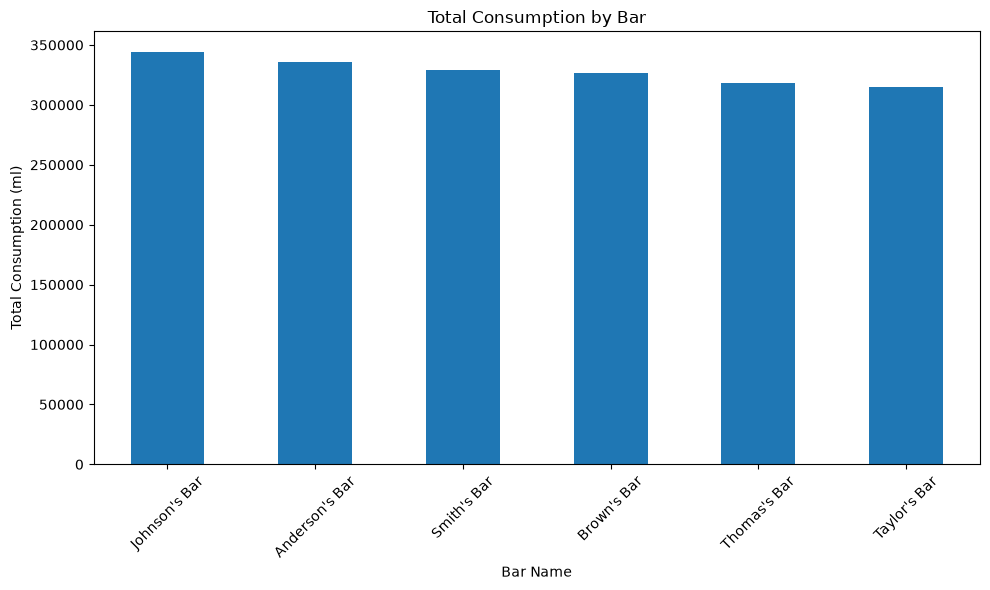

In [59]:
plt.figure(figsize=(10, 6))

bar_consumption.plot(kind="bar")

plt.title("Total Consumption by Bar")
plt.xlabel("Bar Name")
plt.ylabel("Total Consumption (ml)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
# Calculate total consumption by brand.

brand_consumption = (
    daily_ts.groupby("Brand Name")["Daily Consumption (ml)"]
    .sum()
    .sort_values(ascending=False)
)

brand_consumption

Brand Name
Grey Goose        158924.02
Jim Beam          139702.43
Captain Morgan    138035.53
Barefoot          132312.95
Yellow Tail       129843.65
Smirnoff          129176.67
Bacardi           127951.80
Malibu            127279.51
Jack Daniels      125050.89
Absolut           123659.02
Jameson           120001.14
Sutter Home       117245.66
Miller            107719.33
Coors              97999.32
Heineken           96967.09
Budweiser          96812.65
Name: Daily Consumption (ml), dtype: float64

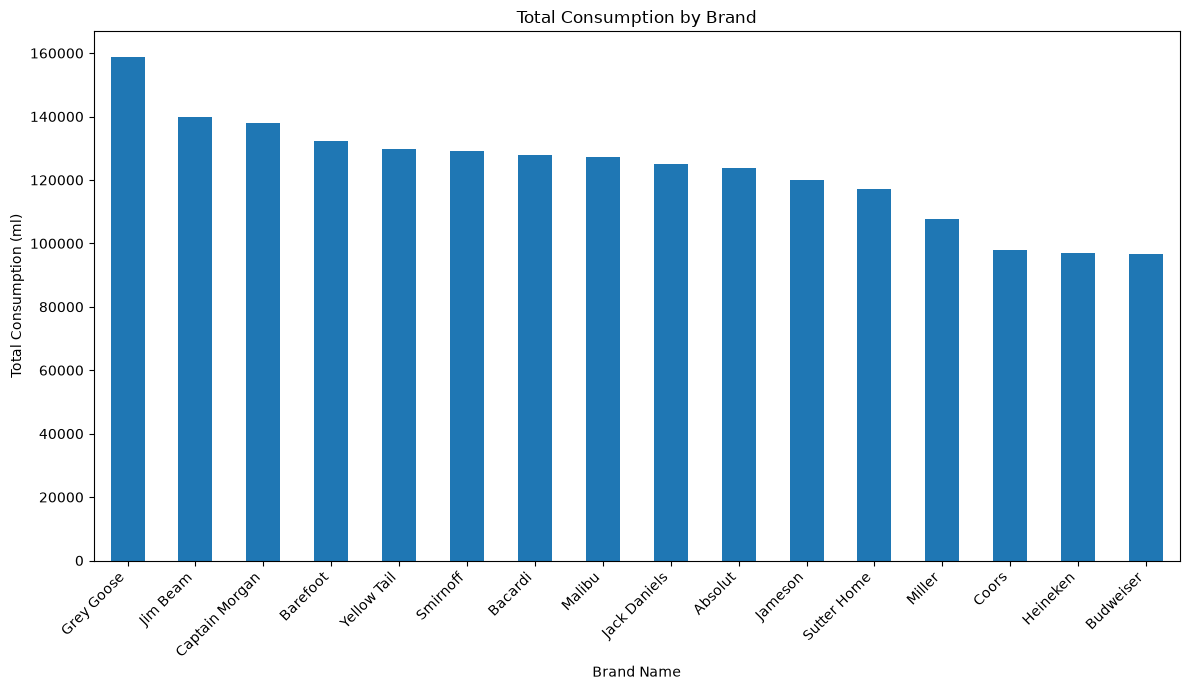

In [61]:
plt.figure(figsize=(12, 7))

brand_consumption.plot(kind="bar")

plt.title("Total Consumption by Brand")
plt.xlabel("Brand Name")
plt.ylabel("Total Consumption (ml)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [62]:
# Calculate total consumption by alcohol type.

alcohol_consumption = (
    daily_ts.groupby("Alcohol Type")["Daily Consumption (ml)"]
    .sum()
    .sort_values(ascending=False)
)

alcohol_consumption

Alcohol Type
Vodka      411759.71
Beer       399498.39
Rum        393266.84
Whiskey    384754.46
Wine       379402.26
Name: Daily Consumption (ml), dtype: float64

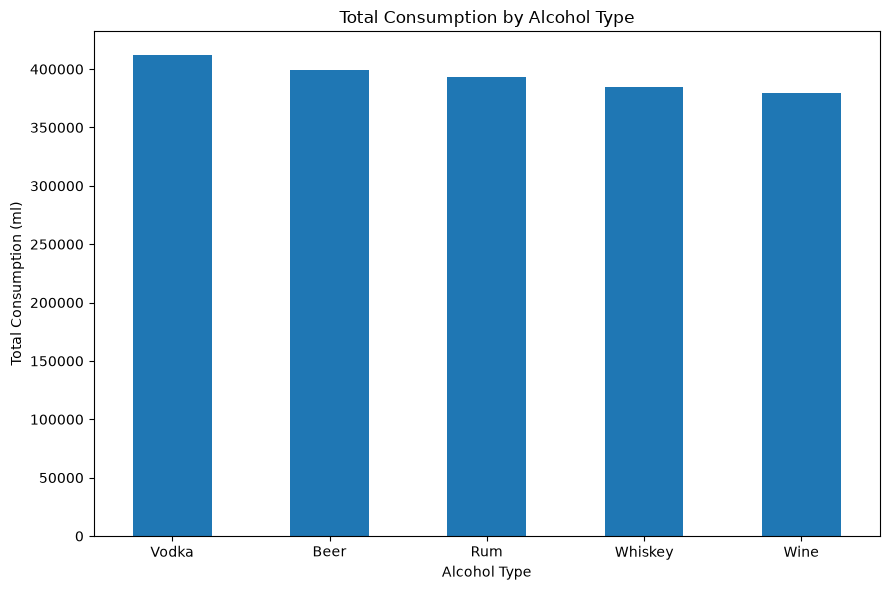

In [63]:
plt.figure(figsize=(9, 6))

alcohol_consumption.plot(kind="bar")

plt.title("Total Consumption by Alcohol Type")
plt.xlabel("Alcohol Type")
plt.ylabel("Total Consumption (ml)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [64]:
# Aggregate consumption across all bars and brands by date.

overall_daily_consumption = (
    daily_ts.groupby("Date")["Daily Consumption (ml)"]
    .sum()
    .reset_index()
)

overall_daily_consumption.head()

,Date,Daily Consumption (ml)
0,2023-01-01,0.00
1,2023-01-02,6601.69
2,2023-01-03,7124.15
3,2023-01-04,6065.93
4,2023-01-05,8048.48


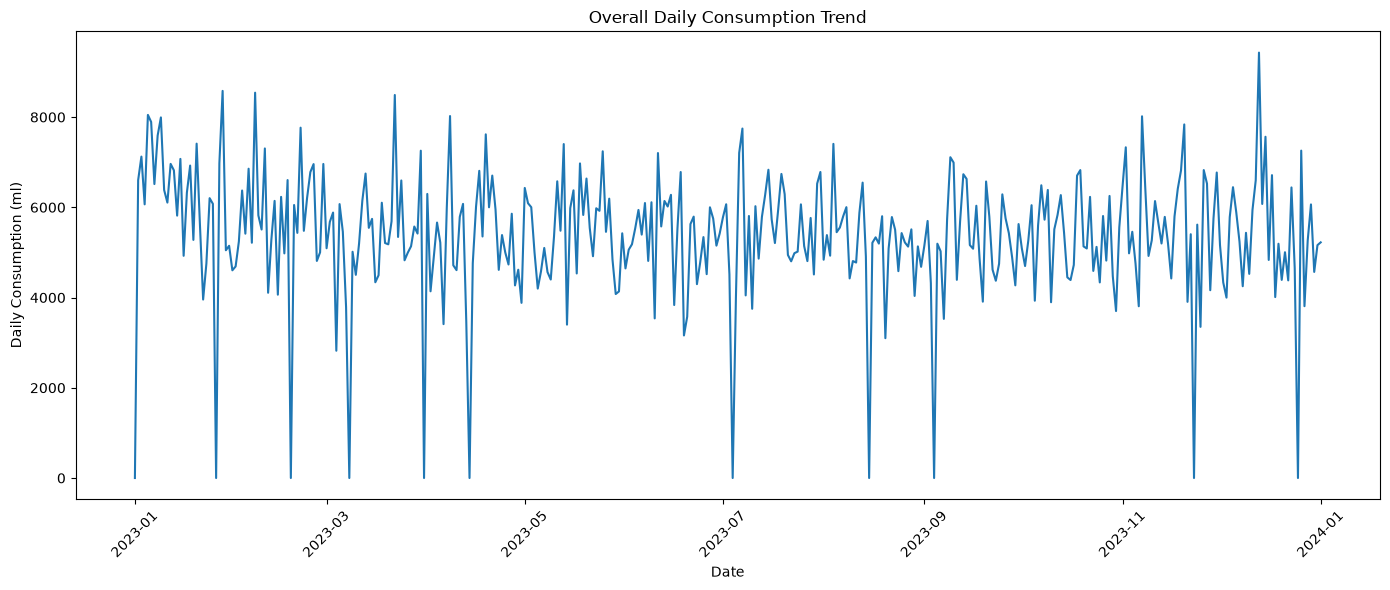

In [65]:
plt.figure(figsize=(14, 6))

plt.plot(
    overall_daily_consumption["Date"],
    overall_daily_consumption["Daily Consumption (ml)"]
)

plt.title("Overall Daily Consumption Trend")
plt.xlabel("Date")
plt.ylabel("Daily Consumption (ml)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [66]:
# Add day-of-week information.

daily_ts["Day of Week"] = daily_ts["Date"].dt.day_name()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_ts["Day of Week"] = pd.Categorical(
    daily_ts["Day of Week"],
    categories=day_order,
    ordered=True
)

print("Day-of-week information added.")

Day-of-week information added.


In [67]:
# Calculate average consumption by day of week.

dow_consumption = (
    daily_ts.groupby(
        "Day of Week",
        observed=True
    )["Daily Consumption (ml)"]
    .mean()
    .reindex(day_order)
)

dow_consumption

Day of Week
Monday       53.224733
Tuesday      56.017458
Wednesday    58.503101
Thursday     55.643606
Friday       56.826180
Saturday     56.474858
Sunday       55.584892
Name: Daily Consumption (ml), dtype: float64

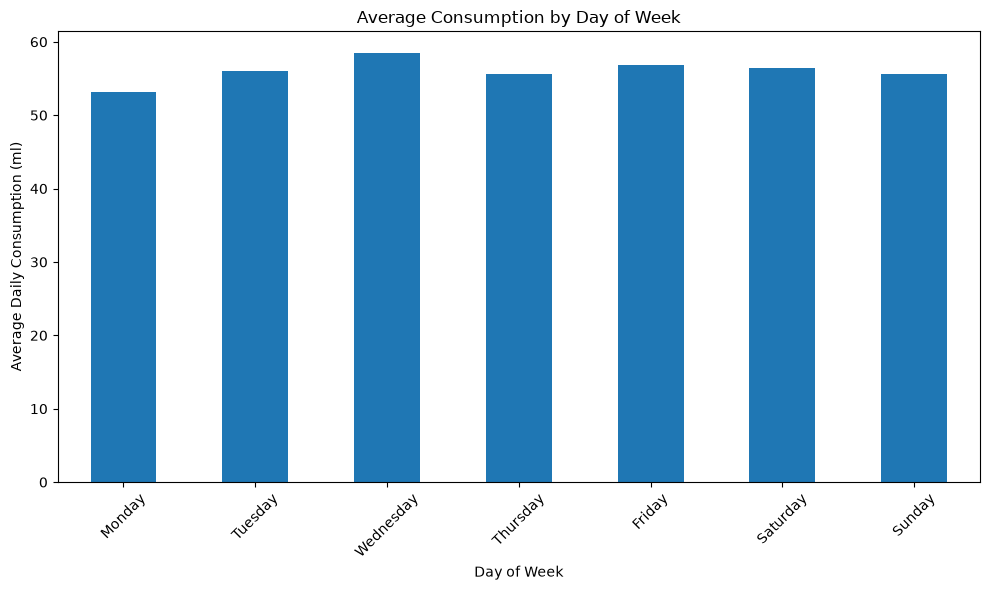

In [68]:
plt.figure(figsize=(10, 6))

dow_consumption.plot(kind="bar")

plt.title("Average Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Consumption (ml)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [69]:
# Compare average consumption on Friday and Saturday.

friday_saturday = (
    dow_consumption.loc[["Friday", "Saturday"]]
)

friday_saturday

Day of Week
Friday      56.826180
Saturday    56.474858
Name: Daily Consumption (ml), dtype: float64

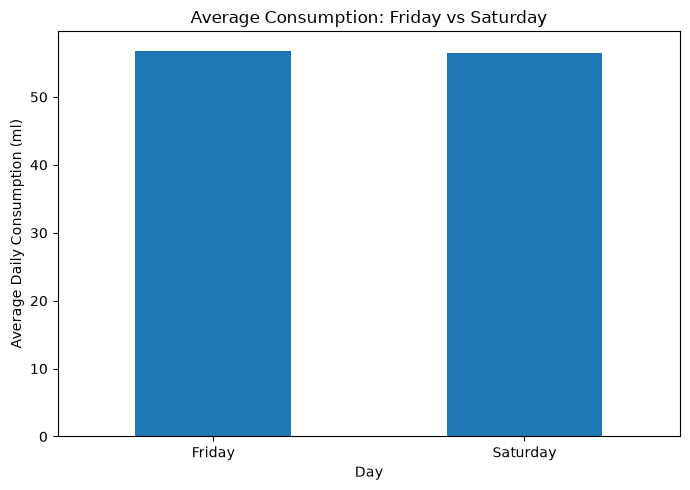

In [70]:
plt.figure(figsize=(7, 5))

friday_saturday.plot(kind="bar")

plt.title("Average Consumption: Friday vs Saturday")
plt.xlabel("Day")
plt.ylabel("Average Daily Consumption (ml)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [71]:
# Classify days into weekday and weekend.

daily_ts["Day Type"] = np.where(
    daily_ts["Date"].dt.dayofweek >= 5,
    "Weekend",
    "Weekday"
)

day_type_consumption = (
    daily_ts.groupby("Day Type")["Daily Consumption (ml)"]
    .mean()
    .sort_values(ascending=False)
)

day_type_consumption

Day Type
Weekday    56.032217
Weekend    56.025637
Name: Daily Consumption (ml), dtype: float64

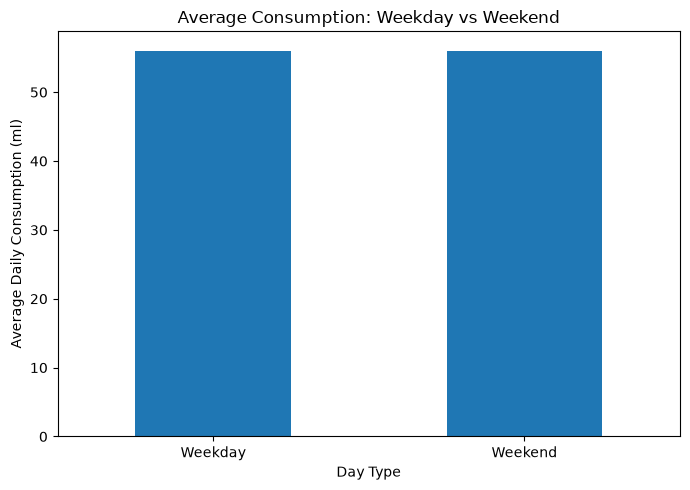

In [72]:
plt.figure(figsize=(7, 5))

day_type_consumption.plot(kind="bar")

plt.title("Average Consumption: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Daily Consumption (ml)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [73]:
# Calculate monthly total consumption.

monthly_consumption = (
    daily_ts
    .set_index("Date")
    .resample("MS")["Daily Consumption (ml)"]
    .sum()
)

monthly_consumption

Date
2023-01-01    184847.00
2023-02-01    159822.30
2023-03-01    158339.96
2023-04-01    155860.16
2023-05-01    170649.44
2023-06-01    159086.67
2023-07-01    167976.64
2023-08-01    157453.30
2023-09-01    155618.19
2023-10-01    164376.69
2023-11-01    165006.98
2023-12-01    164420.62
2024-01-01      5223.71
Freq: MS, Name: Daily Consumption (ml), dtype: float64

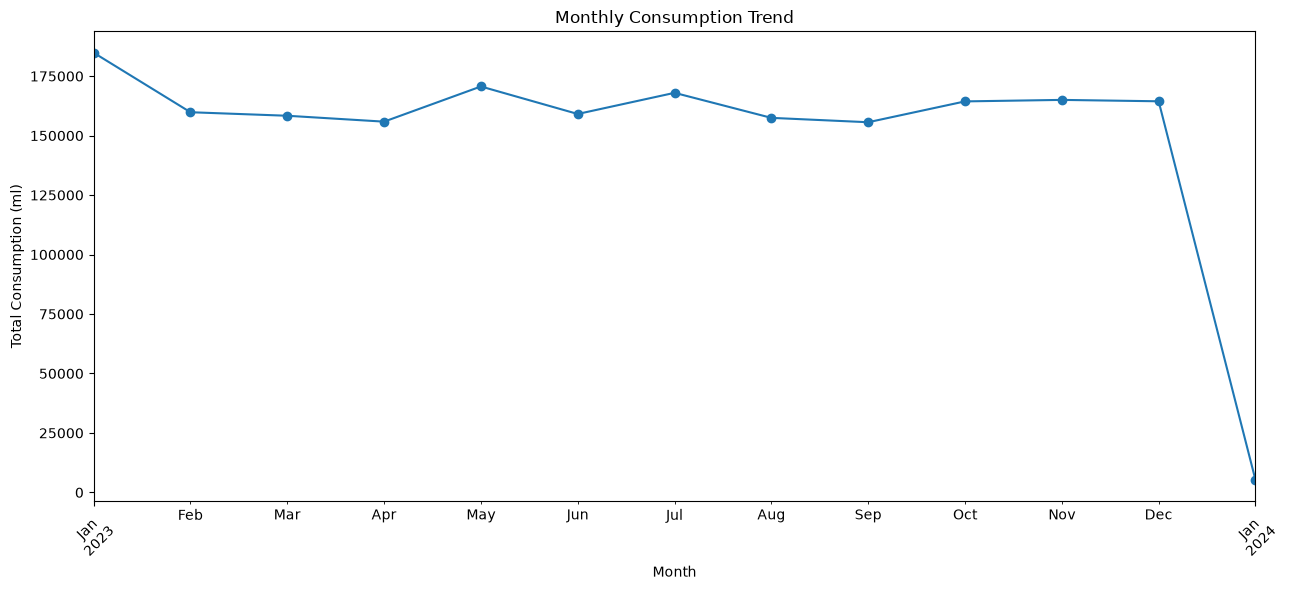

In [74]:
plt.figure(figsize=(13, 6))

monthly_consumption.plot(kind="line", marker="o")

plt.title("Monthly Consumption Trend")
plt.xlabel("Month")
plt.ylabel("Total Consumption (ml)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [75]:
# Calculate average daily consumption for each month.

monthly_avg_consumption = (
    daily_ts
    .assign(Month=daily_ts["Date"].dt.to_period("M"))
    .groupby("Month")["Daily Consumption (ml)"]
    .mean()
)

monthly_avg_consumption

Month
2023-01    62.112567
2023-02    59.457701
2023-03    53.205632
2023-04    54.118111
2023-05    57.341882
2023-06    55.238427
2023-07    56.443763
2023-08    52.907695
2023-09    54.034094
2023-10    55.234103
2023-11    57.294090
2023-12    55.248864
2024-01    54.413646
Freq: M, Name: Daily Consumption (ml), dtype: float64

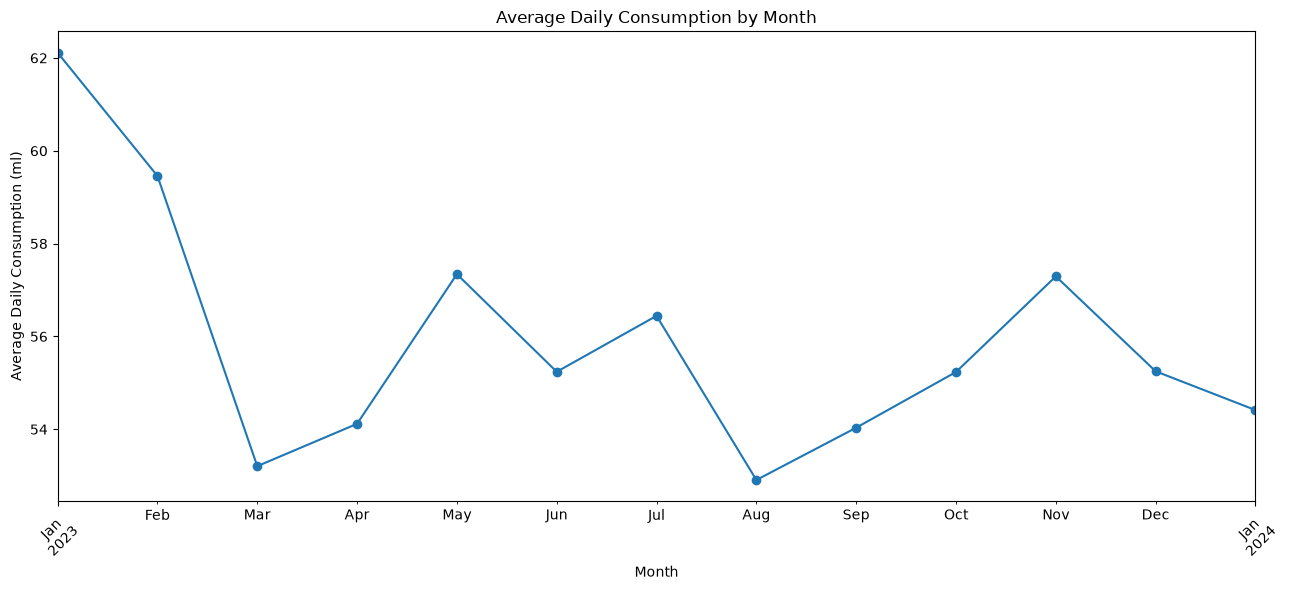

In [76]:
plt.figure(figsize=(13, 6))

monthly_avg_consumption.plot(kind="line", marker="o")

plt.title("Average Daily Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Consumption (ml)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [77]:
# Create a concise EDA summary.

eda_summary = pd.DataFrame({
    "Metric": [
        "Total Consumption",
        "Average Daily Consumption",
        "Median Daily Consumption",
        "Maximum Daily Consumption",
        "Minimum Daily Consumption",
        "Highest Consumption Bar",
        "Highest Consumption Brand",
        "Highest Consumption Alcohol Type",
        "Highest Average Consumption Day"
    ],
    "Value": [
        f"{daily_ts['Daily Consumption (ml)'].sum():,.2f} ml",
        f"{daily_ts['Daily Consumption (ml)'].mean():,.2f} ml",
        f"{daily_ts['Daily Consumption (ml)'].median():,.2f} ml",
        f"{daily_ts['Daily Consumption (ml)'].max():,.2f} ml",
        f"{daily_ts['Daily Consumption (ml)'].min():,.2f} ml",
        bar_consumption.idxmax(),
        brand_consumption.idxmax(),
        alcohol_consumption.idxmax(),
        dow_consumption.idxmax()
    ]
})

eda_summary

,Metric,Value
0,Total Consumption,"1,968,681.66 ml"
1,Average Daily Consumption,56.03 ml
2,Median Daily Consumption,0.00 ml
3,Maximum Daily Consumption,"1,180.58 ml"
4,Minimum Daily Consumption,0.00 ml
5,Highest Consumption Bar,Johnson's Bar
6,Highest Consumption Brand,Grey Goose
7,Highest Consumption Alcohol Type,Vodka
8,Highest Average Consumption Day,Wednesday


### EDA Conclusion

The exploratory analysis provides an initial understanding of inventory consumption behavior across bars, brands, alcohol types, and time.

The analysis examined:

- Bar-level consumption differences
- Brand-level demand concentration
- Alcohol-type consumption
- Overall daily consumption trends
- Day-of-week demand patterns
- Friday and Saturday consumption
- Weekday versus weekend demand
- Monthly consumption patterns

These observations will be used in the next stages to identify high-velocity inventory items, classify products using ABC analysis, and investigate demand seasonality before forecasting.

# 8. ABC Analysis

ABC analysis is used to classify brands based on their historical consumption velocity.

The classification helps prioritize inventory management:

- Category A: High-velocity brands requiring close monitoring.
- Category B: Medium-velocity brands requiring regular monitoring.
- Category C: Lower-velocity brands requiring relatively less frequent monitoring.

The classification is based on cumulative historical consumption.

In [81]:
# Calculate total historical consumption for each brand.

abc_analysis = (
    daily_ts.groupby(
        ["Brand Name", "Alcohol Type"],
        as_index=False
    )["Daily Consumption (ml)"]
    .sum()
    .rename(columns={
        "Daily Consumption (ml)": "Total Consumption (ml)"
    })
)

abc_analysis = abc_analysis.sort_values(
    "Total Consumption (ml)",
    ascending=False
).reset_index(drop=True)

abc_analysis

,Brand Name,Alcohol Type,Total Consumption (ml)
0,Grey Goose,Vodka,158924.02
1,Jim Beam,Whiskey,139702.43
2,Captain Morgan,Rum,138035.53
3,Barefoot,Wine,132312.95
4,Yellow Tail,Wine,129843.65
5,Smirnoff,Vodka,129176.67
6,Bacardi,Rum,127951.80
7,Malibu,Rum,127279.51
8,Jack Daniels,Whiskey,125050.89
9,Absolut,Vodka,123659.02


In [82]:
# Calculate each brand's percentage contribution to total consumption.

total_consumption = abc_analysis["Total Consumption (ml)"].sum()

abc_analysis["Consumption Percentage (%)"] = (
    abc_analysis["Total Consumption (ml)"]
    / total_consumption
    * 100
)

abc_analysis

,Brand Name,Alcohol Type,Total Consumption (ml),Consumption Percentage (%)
0,Grey Goose,Vodka,158924.02,8.072611
1,Jim Beam,Whiskey,139702.43,7.096243
2,Captain Morgan,Rum,138035.53,7.011572
3,Barefoot,Wine,132312.95,6.720891
4,Yellow Tail,Wine,129843.65,6.595462
5,Smirnoff,Vodka,129176.67,6.561582
6,Bacardi,Rum,127951.80,6.499365
7,Malibu,Rum,127279.51,6.465215
8,Jack Daniels,Whiskey,125050.89,6.352012
9,Absolut,Vodka,123659.02,6.281311


In [83]:
# Calculate cumulative consumption percentage.

abc_analysis["Cumulative Consumption (%)"] = (
    abc_analysis["Consumption Percentage (%)"]
    .cumsum()
)

abc_analysis

,Brand Name,Alcohol Type,Total Consumption (ml),Consumption Percentage (%),Cumulative Consumption (%)
0,Grey Goose,Vodka,158924.02,8.072611,8.072611
1,Jim Beam,Whiskey,139702.43,7.096243,15.168854
2,Captain Morgan,Rum,138035.53,7.011572,22.180426
3,Barefoot,Wine,132312.95,6.720891,28.901317
4,Yellow Tail,Wine,129843.65,6.595462,35.496779
5,Smirnoff,Vodka,129176.67,6.561582,42.058362
6,Bacardi,Rum,127951.80,6.499365,48.557726
7,Malibu,Rum,127279.51,6.465215,55.022942
8,Jack Daniels,Whiskey,125050.89,6.352012,61.374953
9,Absolut,Vodka,123659.02,6.281311,67.656264


In [84]:
# Assign ABC categories based on cumulative consumption.

def assign_abc_category(cumulative_percentage):
    if cumulative_percentage <= 70:
        return "A"
    elif cumulative_percentage <= 90:
        return "B"
    else:
        return "C"


abc_analysis["ABC Category"] = (
    abc_analysis["Cumulative Consumption (%)"]
    .apply(assign_abc_category)
)

abc_analysis

,Brand Name,Alcohol Type,Total Consumption (ml),Consumption Percentage (%),Cumulative Consumption (%),ABC Category
0,Grey Goose,Vodka,158924.02,8.072611,8.072611,A
1,Jim Beam,Whiskey,139702.43,7.096243,15.168854,A
2,Captain Morgan,Rum,138035.53,7.011572,22.180426,A
3,Barefoot,Wine,132312.95,6.720891,28.901317,A
4,Yellow Tail,Wine,129843.65,6.595462,35.496779,A
5,Smirnoff,Vodka,129176.67,6.561582,42.058362,A
6,Bacardi,Rum,127951.80,6.499365,48.557726,A
7,Malibu,Rum,127279.51,6.465215,55.022942,A
8,Jack Daniels,Whiskey,125050.89,6.352012,61.374953,A
9,Absolut,Vodka,123659.02,6.281311,67.656264,A


In [85]:
# Count brands in each ABC category.

abc_counts = (
    abc_analysis["ABC Category"]
    .value_counts()
    .reindex(["A", "B", "C"], fill_value=0)
)

abc_counts

ABC Category
A    10
B     3
C     3
Name: count, dtype: int64

In [86]:
# Summarize consumption by ABC category.

abc_summary = (
    abc_analysis
    .groupby("ABC Category", as_index=False)
    ["Total Consumption (ml)"]
    .sum()
)

abc_summary["Consumption Percentage (%)"] = (
    abc_summary["Total Consumption (ml)"]
    / abc_summary["Total Consumption (ml)"].sum()
    * 100
)

abc_summary = (
    abc_summary
    .set_index("ABC Category")
    .reindex(["A", "B", "C"])
    .reset_index()
)

abc_summary

,ABC Category,Total Consumption (ml),Consumption Percentage (%)
0,A,1331936.47,67.656264
1,B,344966.13,17.522697
2,C,291779.06,14.821038


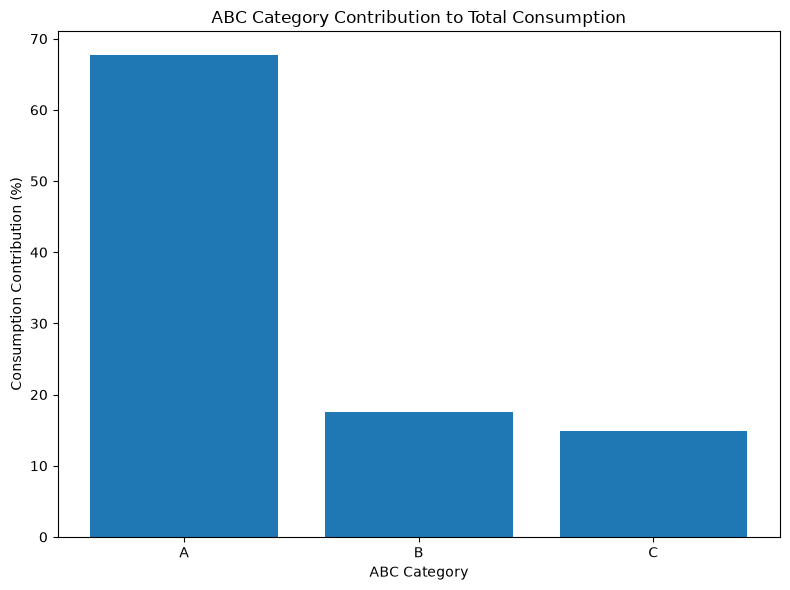

In [87]:
plt.figure(figsize=(8, 6))

plt.bar(
    abc_summary["ABC Category"],
    abc_summary["Consumption Percentage (%)"]
)

plt.title("ABC Category Contribution to Total Consumption")
plt.xlabel("ABC Category")
plt.ylabel("Consumption Contribution (%)")

plt.tight_layout()
plt.show()

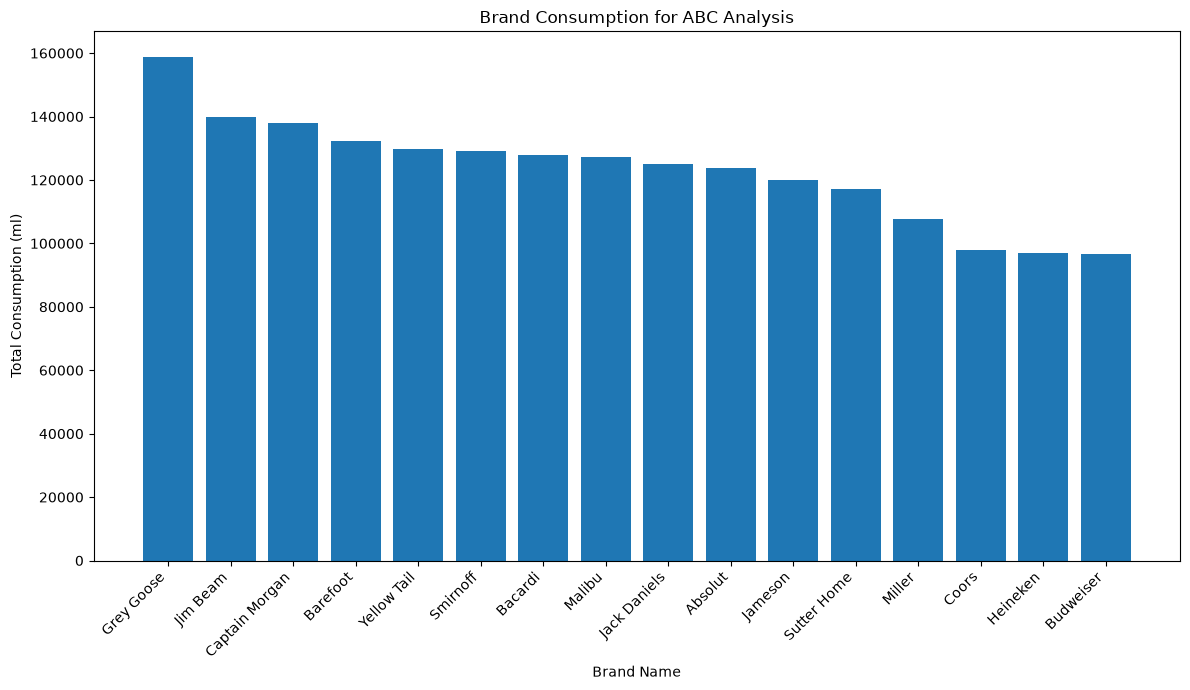

In [88]:
plt.figure(figsize=(12, 7))

plt.bar(
    abc_analysis["Brand Name"],
    abc_analysis["Total Consumption (ml)"]
)

plt.title("Brand Consumption for ABC Analysis")
plt.xlabel("Brand Name")
plt.ylabel("Total Consumption (ml)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [89]:
# Final ABC analysis table.

abc_final = abc_analysis[
    [
        "Brand Name",
        "Alcohol Type",
        "Total Consumption (ml)",
        "Consumption Percentage (%)",
        "Cumulative Consumption (%)",
        "ABC Category"
    ]
].copy()

abc_final

,Brand Name,Alcohol Type,Total Consumption (ml),Consumption Percentage (%),Cumulative Consumption (%),ABC Category
0,Grey Goose,Vodka,158924.02,8.072611,8.072611,A
1,Jim Beam,Whiskey,139702.43,7.096243,15.168854,A
2,Captain Morgan,Rum,138035.53,7.011572,22.180426,A
3,Barefoot,Wine,132312.95,6.720891,28.901317,A
4,Yellow Tail,Wine,129843.65,6.595462,35.496779,A
5,Smirnoff,Vodka,129176.67,6.561582,42.058362,A
6,Bacardi,Rum,127951.80,6.499365,48.557726,A
7,Malibu,Rum,127279.51,6.465215,55.022942,A
8,Jack Daniels,Whiskey,125050.89,6.352012,61.374953,A
9,Absolut,Vodka,123659.02,6.281311,67.656264,A


In [90]:
# Create a business summary for each ABC category.

abc_business_summary = (
    abc_final
    .groupby("ABC Category")
    .agg(
        Number_of_Brands=("Brand Name", "count"),
        Total_Consumption_ml=("Total Consumption (ml)", "sum")
    )
    .reindex(["A", "B", "C"])
)

abc_business_summary["Consumption_Share_Percent"] = (
    abc_business_summary["Total_Consumption_ml"]
    / abc_business_summary["Total_Consumption_ml"].sum()
    * 100
)

abc_business_summary

,Number_of_Brands,Total_Consumption_ml,Consumption_Share_Percent
ABC Category,,,
A,10,1331936.47,67.656264
B,3,344966.13,17.522697
C,3,291779.06,14.821038


In [91]:
# Save ABC classification results.

abc_output_path = "../data/processed/abc_brand_classification.csv"

abc_final.to_csv(
    abc_output_path,
    index=False
)

print("ABC analysis saved successfully.")
print("File:", abc_output_path)

ABC analysis saved successfully.
File: ../data/processed/abc_brand_classification.csv


### ABC Analysis Conclusion

ABC analysis classified brands according to their historical consumption velocity.

Category A represents the highest-consumption brands and should receive closer inventory monitoring because demand changes for these items can have a larger operational impact.

Category B represents medium-consumption brands that require regular inventory monitoring.

Category C represents lower-consumption brands where inventory monitoring can generally be less frequent.

The ABC classification will be used as an additional business segmentation when interpreting forecasting and inventory-management results.

# 9. Day-of-Week and Seasonality Analysis

Demand for bar inventory may vary systematically by day of the week and by month.

This analysis investigates recurring temporal patterns in consumption, including:

1. Day-of-week demand patterns
2. Bar-specific weekly demand patterns
3. Brand-specific weekly demand patterns
4. Friday and Saturday demand
5. Weekday versus weekend demand
6. Monthly seasonality
7. Interaction between month and day of week

The findings will help identify useful seasonal features for demand forecasting.

In [94]:
# Verify the day-of-week column.

print("Day of Week values:")
print(daily_ts["Day of Week"].value_counts().sort_index())

Day of Week values:
Day of Week
Monday       5088
Tuesday      4992
Wednesday    4992
Thursday     4992
Friday       4992
Saturday     4992
Sunday       5088
Name: count, dtype: int64


In [95]:
# Calculate average daily consumption for each day of the week.

weekly_pattern = (
    daily_ts.groupby(
        "Day of Week",
        observed=True
    )["Daily Consumption (ml)"]
    .mean()
    .reindex(day_order)
)

weekly_pattern

Day of Week
Monday       53.224733
Tuesday      56.017458
Wednesday    58.503101
Thursday     55.643606
Friday       56.826180
Saturday     56.474858
Sunday       55.584892
Name: Daily Consumption (ml), dtype: float64

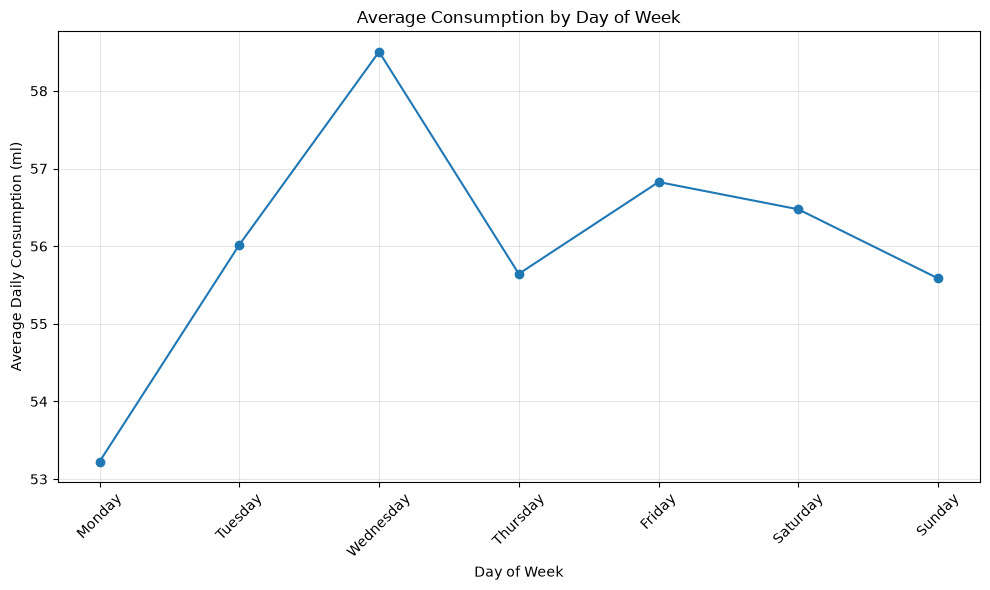

In [96]:
plt.figure(figsize=(10, 6))

plt.plot(
    weekly_pattern.index,
    weekly_pattern.values,
    marker="o"
)

plt.title("Average Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Consumption (ml)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [97]:
# Calculate average consumption by Bar and Day of Week.

bar_weekly_pattern = (
    daily_ts.groupby(
        ["Bar Name", "Day of Week"],
        observed=True
    )["Daily Consumption (ml)"]
    .mean()
    .reset_index()
)

bar_weekly_pattern.head(15)

,Bar Name,Day of Week,Daily Consumption (ml)
0,Anderson's Bar,Monday,50.083561
1,Anderson's Bar,Tuesday,53.208017
2,Anderson's Bar,Wednesday,62.081166
3,Anderson's Bar,Thursday,52.784279
4,Anderson's Bar,Friday,60.278822
5,Anderson's Bar,Saturday,63.543161
6,Anderson's Bar,Sunday,59.541368
7,Brown's Bar,Monday,54.090825
8,Brown's Bar,Tuesday,55.083413
9,Brown's Bar,Wednesday,61.785132


In [98]:
# Convert the Bar-Day pattern into a matrix for visualization.

bar_weekly_pivot = bar_weekly_pattern.pivot(
    index="Bar Name",
    columns="Day of Week",
    values="Daily Consumption (ml)"
)

bar_weekly_pivot = bar_weekly_pivot.reindex(columns=day_order)

bar_weekly_pivot

Day of Week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
Bar Name,,,,,,,
Anderson's Bar,50.083561,53.208017,62.081166,52.784279,60.278822,63.543161,59.541368
Brown's Bar,54.090825,55.083413,61.785132,51.455469,55.931166,56.867837,54.962913
Johnson's Bar,52.591545,60.225817,58.162692,64.705649,62.929483,53.634543,59.282005
Smith's Bar,57.286757,55.010757,61.185349,53.185998,52.605469,55.640601,57.957665
Taylor's Bar,51.397170,55.462969,53.416659,56.030889,52.959579,55.502873,52.058314
Thomas's Bar,53.898538,57.113774,54.387608,55.699351,56.252560,53.660132,49.707087


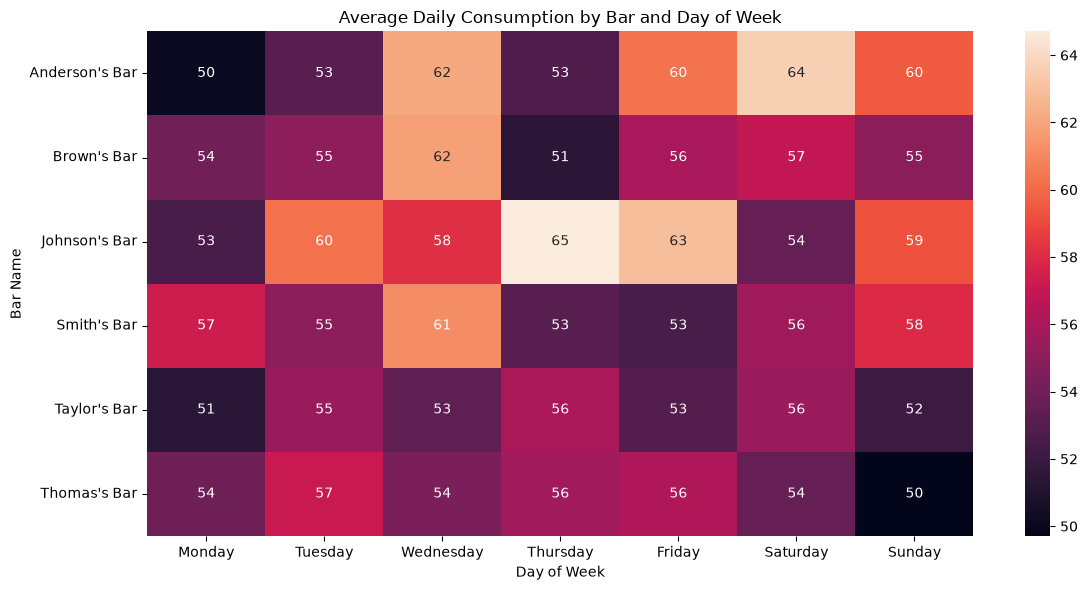

In [99]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    bar_weekly_pivot,
    annot=True,
    fmt=".0f"
)

plt.title("Average Daily Consumption by Bar and Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Bar Name")
plt.tight_layout()
plt.show()

In [100]:
# Calculate average consumption by Brand and Day of Week.

brand_weekly_pattern = (
    daily_ts.groupby(
        ["Brand Name", "Day of Week"],
        observed=True
    )["Daily Consumption (ml)"]
    .mean()
    .reset_index()
)

brand_weekly_pivot = brand_weekly_pattern.pivot(
    index="Brand Name",
    columns="Day of Week",
    values="Daily Consumption (ml)"
)

brand_weekly_pivot = brand_weekly_pivot.reindex(
    columns=day_order
)

brand_weekly_pivot

Day of Week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
Brand Name,,,,,,,
Absolut,54.324906,51.903814,55.313686,57.335737,57.974712,52.752212,64.453742
Bacardi,57.690440,76.214423,65.895962,51.251442,47.127500,48.458269,61.177956
Barefoot,43.089182,58.813269,60.127468,69.727660,63.457212,70.114199,56.829465
Budweiser,36.554874,42.230609,43.487756,54.540833,55.482115,47.321635,29.410566
Captain Morgan,69.139780,63.159776,65.063942,48.768814,75.000801,60.053205,58.775346
Coors,33.547547,50.455224,43.244391,42.047276,35.911538,57.335865,49.952767
Grey Goose,69.790157,69.102051,84.594615,56.470321,83.210224,76.854359,66.724843
Heineken,47.638113,49.183045,41.787372,43.769808,43.304263,48.898846,34.628459
Jack Daniels,47.300031,55.690224,63.435673,55.015353,62.298237,58.398494,56.666761


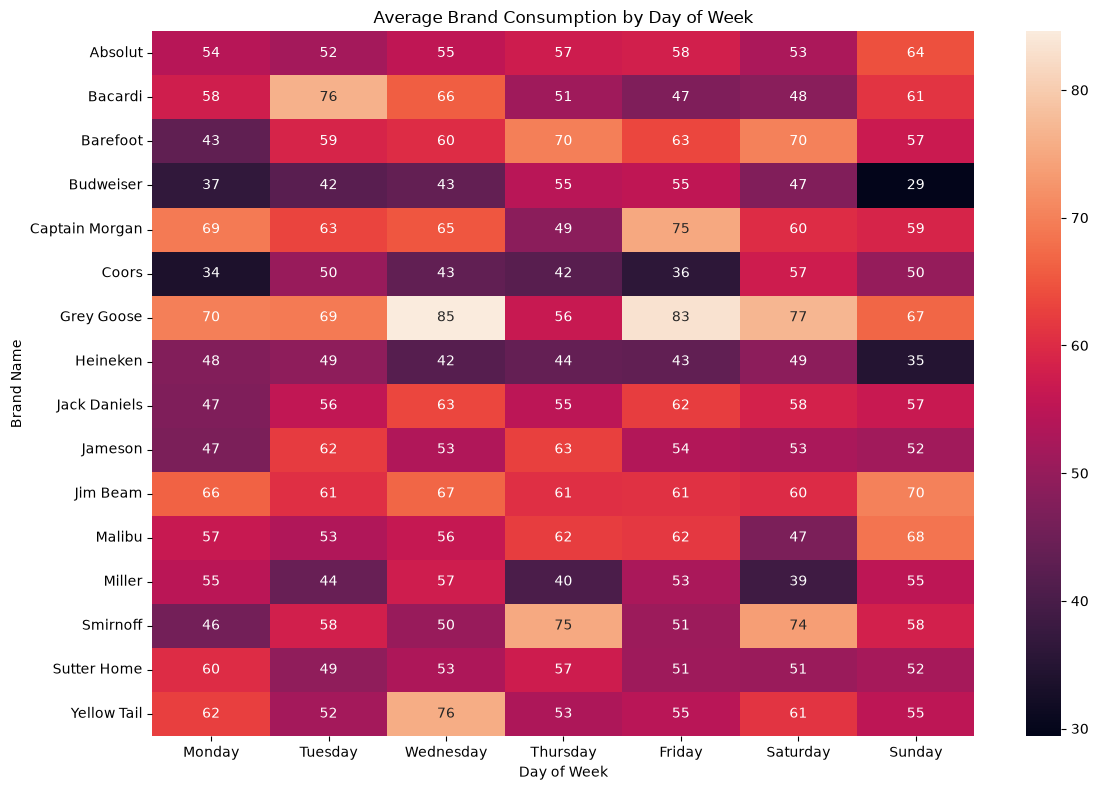

In [101]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    brand_weekly_pivot,
    annot=True,
    fmt=".0f"
)

plt.title("Average Brand Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Brand Name")
plt.tight_layout()
plt.show()

In [102]:
# Compare Friday and Saturday demand.

friday_saturday_analysis = (
    daily_ts[
        daily_ts["Day of Week"].isin(["Friday", "Saturday"])
    ]
    .groupby(
        "Day of Week",
        observed=True
    )["Daily Consumption (ml)"]
    .agg(["mean", "median", "std", "max"])
    .reindex(["Friday", "Saturday"])
)

friday_saturday_analysis

,mean,median,std,max
Day of Week,,,,
Friday,56.826180,0.0,146.465924,1145.17
Saturday,56.474858,0.0,145.253116,1097.26


In [103]:
# Calculate the percentage difference between Saturday and Friday average demand.

friday_avg = friday_saturday_analysis.loc["Friday", "mean"]
saturday_avg = friday_saturday_analysis.loc["Saturday", "mean"]

friday_saturday_difference = (
    (saturday_avg - friday_avg)
    / friday_avg
    * 100
)

print(f"Friday average demand: {friday_avg:,.2f} ml")
print(f"Saturday average demand: {saturday_avg:,.2f} ml")
print(
    f"Saturday vs Friday difference: "
    f"{friday_saturday_difference:.2f}%"
)

Friday average demand: 56.83 ml
Saturday average demand: 56.47 ml
Saturday vs Friday difference: -0.62%


In [104]:
# Classify each date as Weekday or Weekend.

daily_ts["Day Type"] = np.where(
    daily_ts["Date"].dt.dayofweek >= 5,
    "Weekend",
    "Weekday"
)

weekday_weekend = (
    daily_ts.groupby("Day Type")["Daily Consumption (ml)"]
    .agg(["mean", "median", "std", "max"])
    .reindex(["Weekday", "Weekend"])
)

weekday_weekend

,mean,median,std,max
Day Type,,,,
Weekday,56.032217,0.0,143.264277,1180.58
Weekend,56.025637,0.0,143.313960,1176.86


In [105]:
weekday_avg = weekday_weekend.loc["Weekday", "mean"]
weekend_avg = weekday_weekend.loc["Weekend", "mean"]

weekend_difference = (
    (weekend_avg - weekday_avg)
    / weekday_avg
    * 100
)

print(f"Weekday average demand: {weekday_avg:,.2f} ml")
print(f"Weekend average demand: {weekend_avg:,.2f} ml")
print(
    f"Weekend vs Weekday difference: "
    f"{weekend_difference:.2f}%"
)

Weekday average demand: 56.03 ml
Weekend average demand: 56.03 ml
Weekend vs Weekday difference: -0.01%


In [106]:
# Add month information.

daily_ts["Month"] = daily_ts["Date"].dt.month
daily_ts["Month Name"] = daily_ts["Date"].dt.month_name()

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

daily_ts["Month Name"] = pd.Categorical(
    daily_ts["Month Name"],
    categories=month_order,
    ordered=True
)

In [107]:
# Calculate average daily consumption for each month.

monthly_pattern = (
    daily_ts.groupby(
        "Month Name",
        observed=True
    )["Daily Consumption (ml)"]
    .mean()
    .reindex(month_order)
)

monthly_pattern

Month Name
January      61.871976
February     59.457701
March        53.205632
April        54.118111
May          57.341882
June         55.238427
July         56.443763
August       52.907695
September    54.034094
October      55.234103
November     57.294090
December     55.248864
Name: Daily Consumption (ml), dtype: float64

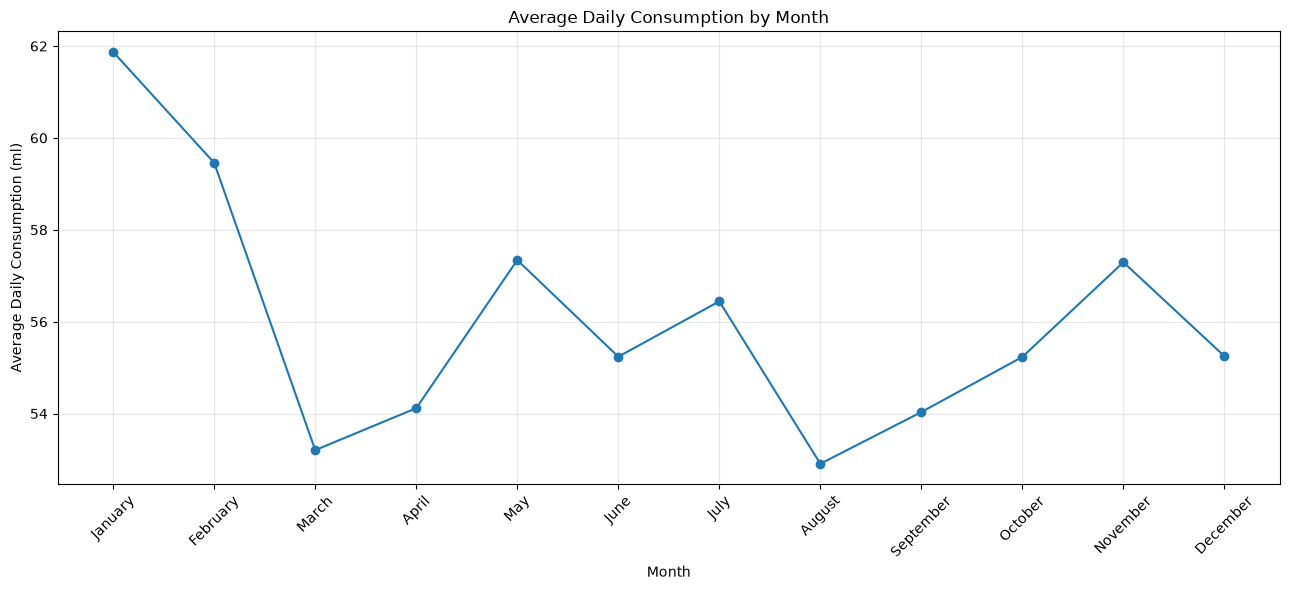

In [108]:
plt.figure(figsize=(13, 6))

plt.plot(
    monthly_pattern.index,
    monthly_pattern.values,
    marker="o"
)

plt.title("Average Daily Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Consumption (ml)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [109]:
# Calculate average consumption by Month and Day of Week.

month_day_pattern = (
    daily_ts.groupby(
        ["Month Name", "Day of Week"],
        observed=True
    )["Daily Consumption (ml)"]
    .mean()
    .reset_index()
)

month_day_pivot = month_day_pattern.pivot(
    index="Month Name",
    columns="Day of Week",
    values="Daily Consumption (ml)"
)

month_day_pivot = month_day_pivot.reindex(
    index=month_order,
    columns=day_order
)

month_day_pivot

Day of Week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
Month Name,,,,,,,
January,60.143281,63.834542,65.557240,52.836172,75.779193,69.159453,49.308521
February,56.752318,71.173307,57.869297,57.131849,70.472396,42.917708,59.887031
March,58.656172,53.639766,51.553312,57.559021,44.743812,49.343932,58.383594
April,56.518698,56.780026,61.571120,48.784427,44.177656,61.774813,48.668312
May,54.103021,56.210729,56.728229,67.178359,54.601901,64.619089,49.197760
June,49.989583,54.977109,61.177734,55.580167,51.506583,49.545703,64.739635
July,52.648438,46.965547,54.047240,62.742031,64.407083,54.110500,60.662875
August,55.481068,43.048104,53.460604,50.705750,59.394635,58.200182,52.940677
September,40.464245,53.502214,61.878906,54.292839,51.953521,58.107375,57.541380


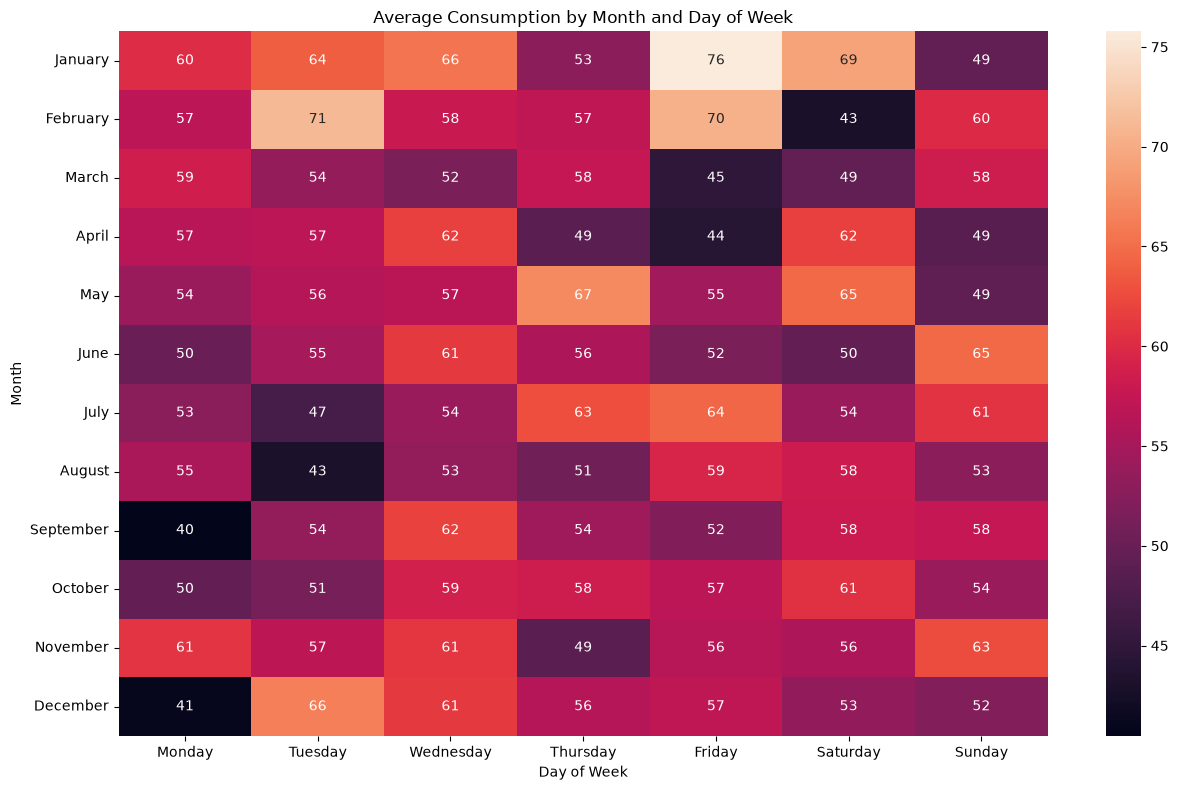

In [110]:
plt.figure(figsize=(13, 8))

sns.heatmap(
    month_day_pivot,
    annot=True,
    fmt=".0f"
)

plt.title("Average Consumption by Month and Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

In [111]:
# Measure variation across the seven days of the week.

weekly_mean = weekly_pattern.mean()
weekly_std = weekly_pattern.std()

weekly_cv = weekly_std / weekly_mean

print(f"Weekly average demand: {weekly_mean:,.2f} ml")
print(f"Weekly standard deviation: {weekly_std:,.2f} ml")
print(f"Weekly coefficient of variation: {weekly_cv:.4f}")

Weekly average demand: 56.04 ml
Weekly standard deviation: 1.59 ml
Weekly coefficient of variation: 0.0284


In [112]:
# Identify the highest and lowest average-demand days.

highest_demand_day = weekly_pattern.idxmax()
lowest_demand_day = weekly_pattern.idxmin()

print("Highest average-demand day:", highest_demand_day)
print("Lowest average-demand day:", lowest_demand_day)

print(
    f"Highest day average consumption: "
    f"{weekly_pattern.max():,.2f} ml"
)

print(
    f"Lowest day average consumption: "
    f"{weekly_pattern.min():,.2f} ml"
)

Highest average-demand day: Wednesday
Lowest average-demand day: Monday
Highest day average consumption: 58.50 ml
Lowest day average consumption: 53.22 ml


In [113]:
# Create a concise seasonality summary.

seasonality_summary = pd.DataFrame({
    "Metric": [
        "Highest Demand Day",
        "Lowest Demand Day",
        "Friday Average Demand",
        "Saturday Average Demand",
        "Saturday vs Friday Difference (%)",
        "Weekday Average Demand",
        "Weekend Average Demand",
        "Weekend vs Weekday Difference (%)",
        "Highest Demand Month",
        "Lowest Demand Month",
        "Weekly Coefficient of Variation"
    ],
    "Value": [
        highest_demand_day,
        lowest_demand_day,
        f"{friday_avg:,.2f} ml",
        f"{saturday_avg:,.2f} ml",
        f"{friday_saturday_difference:.2f}%",
        f"{weekday_avg:,.2f} ml",
        f"{weekend_avg:,.2f} ml",
        f"{weekend_difference:.2f}%",
        monthly_pattern.idxmax(),
        monthly_pattern.idxmin(),
        f"{weekly_cv:.4f}"
    ]
})

seasonality_summary

,Metric,Value
0,Highest Demand Day,Wednesday
1,Lowest Demand Day,Monday
2,Friday Average Demand,56.83 ml
3,Saturday Average Demand,56.47 ml
4,Saturday vs Friday Difference (%),-0.62%
5,Weekday Average Demand,56.03 ml
6,Weekend Average Demand,56.03 ml
7,Weekend vs Weekday Difference (%),-0.01%
8,Highest Demand Month,January
9,Lowest Demand Month,August


In [114]:
# Save the main seasonality summary.

seasonality_output_path = (
    "../data/processed/seasonality_summary.csv"
)

seasonality_summary.to_csv(
    seasonality_output_path,
    index=False
)

print("Seasonality summary saved successfully.")
print("File:", seasonality_output_path)

Seasonality summary saved successfully.
File: ../data/processed/seasonality_summary.csv


### Seasonality Analysis Conclusion

The analysis examined recurring consumption patterns across days of the week and months.

Weekly demand was analyzed at both overall and Bar/Brand levels. Particular attention was given to Friday and Saturday demand because these days may exhibit different consumption behavior.

Weekday versus weekend demand was also compared, while monthly and Month-Day patterns were analyzed to identify potential seasonal effects.

The results from this analysis will help determine which temporal features should be included in the forecasting models, including day-of-week, weekend indicators, and other calendar-based features.

These patterns will also be considered when calculating dynamic inventory requirements and safety stock.

# 10. Historical Stockout Analysis

Historical stockout analysis identifies situations where inventory reached zero while the item had historical consumption demand.

This analysis helps identify Bar-Brand combinations that may require stronger inventory controls, higher safety stock, or more frequent replenishment.

The analysis will examine:

1. Zero closing-balance records
2. Zero closing balance with non-zero consumption
3. Stockout frequency by Bar
4. Stockout frequency by Brand
5. Bar-Brand stockout combinations
6. Consumption associated with stockout records

In [131]:
# Identify records where closing inventory reached zero.

stockout_df = df[
    df["Closing Balance (ml)"] == 0
].copy()

print(
    "Records with zero closing balance:",
    len(stockout_df)
)

stockout_df.head()

Records with zero closing balance: 416


,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),Expected Closing Balance (ml),Balance Difference (ml),Conservation Check,Date
84,2023-01-05 12:48:00,Taylor's Bar,Beer,Heineken,398.16,0.00,398.16,0.00,0.00,0.00,True,2023-01-05
102,2023-01-06 11:51:00,Brown's Bar,Rum,Bacardi,145.81,0.00,145.81,0.00,0.00,0.00,True,2023-01-06
133,2023-01-07 22:34:00,Thomas's Bar,Beer,Coors,161.86,0.00,161.86,0.00,0.00,0.00,True,2023-01-07
194,2023-01-11 16:04:00,Smith's Bar,Whiskey,Jim Beam,487.92,0.00,487.92,0.00,0.00,0.00,True,2023-01-11
198,2023-01-11 18:14:00,Johnson's Bar,Whiskey,Jim Beam,319.86,0.00,319.86,0.00,0.00,0.00,True,2023-01-11


In [132]:
# Identify zero-closing-balance records where consumption was non-zero.

stockout_demand_df = stockout_df[
    stockout_df["Consumed (ml)"] > 0
].copy()

print(
    "Zero-closing records with non-zero consumption:",
    len(stockout_demand_df)
)

stockout_demand_df.head()

Zero-closing records with non-zero consumption: 102


,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),Expected Closing Balance (ml),Balance Difference (ml),Conservation Check,Date
84,2023-01-05 12:48:00,Taylor's Bar,Beer,Heineken,398.16,0.00,398.16,0.00,0.00,0.00,True,2023-01-05
102,2023-01-06 11:51:00,Brown's Bar,Rum,Bacardi,145.81,0.00,145.81,0.00,0.00,0.00,True,2023-01-06
133,2023-01-07 22:34:00,Thomas's Bar,Beer,Coors,161.86,0.00,161.86,0.00,0.00,0.00,True,2023-01-07
194,2023-01-11 16:04:00,Smith's Bar,Whiskey,Jim Beam,487.92,0.00,487.92,0.00,0.00,0.00,True,2023-01-11
198,2023-01-11 18:14:00,Johnson's Bar,Whiskey,Jim Beam,319.86,0.00,319.86,0.00,0.00,0.00,True,2023-01-11


In [133]:
# Calculate the proportion of zero-closing records
# that also had non-zero consumption.

if len(stockout_df) > 0:
    stockout_demand_percentage = (
        len(stockout_demand_df)
        / len(stockout_df)
        * 100
    )
else:
    stockout_demand_percentage = 0

print(
    f"Zero-closing records with non-zero consumption: "
    f"{stockout_demand_percentage:.2f}%"
)

Zero-closing records with non-zero consumption: 24.52%


In [134]:
# Count historical zero-closing events by bar.

stockout_by_bar = (
    stockout_df
    .groupby("Bar Name")
    .size()
    .sort_values(ascending=False)
)

stockout_by_bar

Bar Name
Thomas's Bar      103
Taylor's Bar       94
Brown's Bar        78
Anderson's Bar     73
Smith's Bar        37
Johnson's Bar      31
dtype: int64

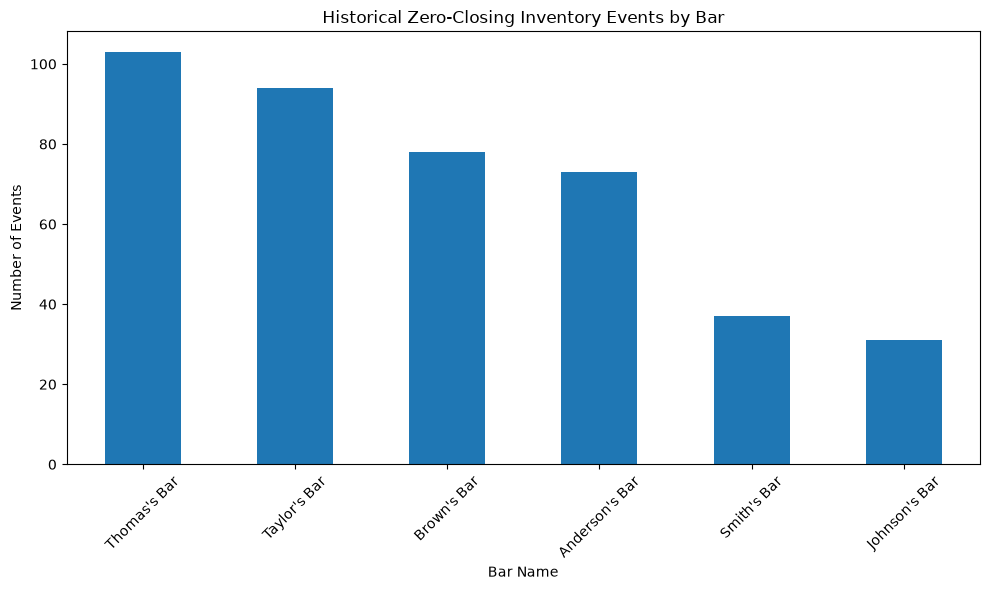

In [135]:
plt.figure(figsize=(10, 6))

stockout_by_bar.plot(kind="bar")

plt.title("Historical Zero-Closing Inventory Events by Bar")
plt.xlabel("Bar Name")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [136]:
# Count historical zero-closing events by brand.

stockout_by_brand = (
    stockout_df
    .groupby("Brand Name")
    .size()
    .sort_values(ascending=False)
)

stockout_by_brand

Brand Name
Yellow Tail       81
Jameson           44
Malibu            36
Budweiser         32
Coors             29
Heineken          28
Smirnoff          26
Sutter Home       25
Jim Beam          24
Miller            21
Captain Morgan    17
Grey Goose        15
Absolut           13
Bacardi           10
Jack Daniels       8
Barefoot           7
dtype: int64

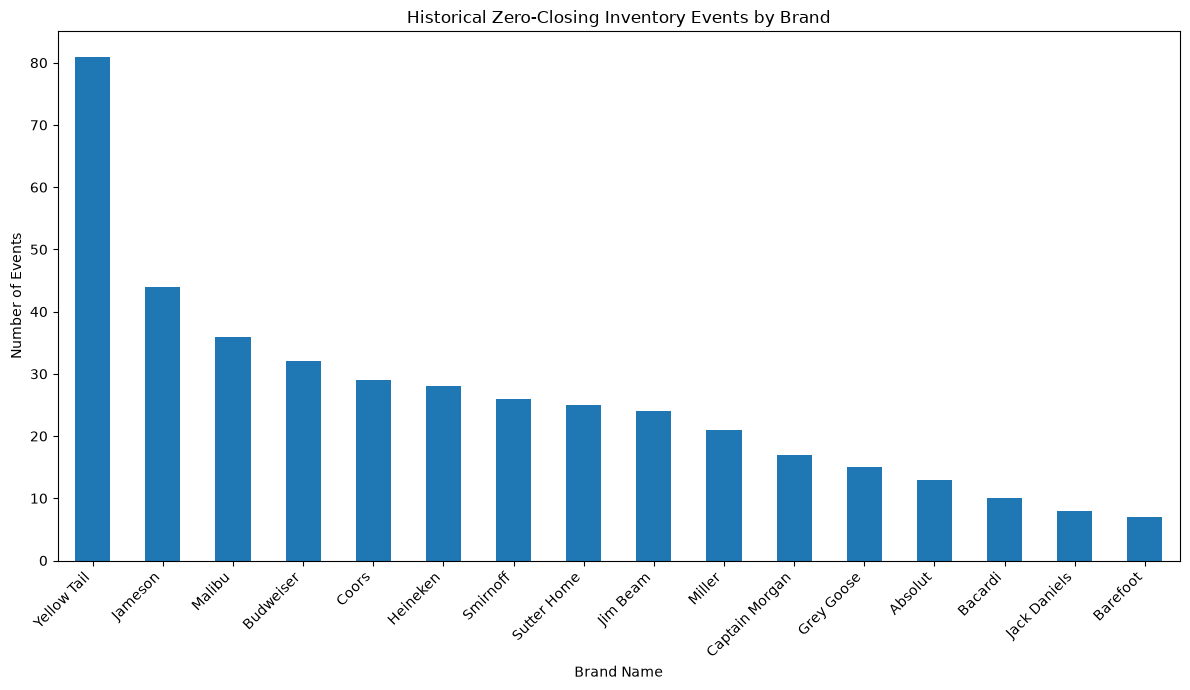

In [137]:
plt.figure(figsize=(12, 7))

stockout_by_brand.plot(kind="bar")

plt.title("Historical Zero-Closing Inventory Events by Brand")
plt.xlabel("Brand Name")
plt.ylabel("Number of Events")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [138]:
# Count zero-closing events for each Bar-Brand combination.

stockout_by_bar_brand = (
    stockout_df
    .groupby(
        ["Bar Name", "Brand Name"]
    )
    .size()
    .reset_index(name="Stockout Events")
    .sort_values(
        "Stockout Events",
        ascending=False
    )
)

stockout_by_bar_brand.head(20)

,Bar Name,Brand Name,Stockout Events
40,Taylor's Bar,Yellow Tail,29
49,Thomas's Bar,Yellow Tail,29
46,Thomas's Bar,Jameson,27
15,Brown's Bar,Smirnoff,25
39,Taylor's Bar,Sutter Home,24
7,Anderson's Bar,Yellow Tail,22
4,Anderson's Bar,Heineken,18
1,Anderson's Bar,Budweiser,16
11,Brown's Bar,Captain Morgan,15
14,Brown's Bar,Malibu,13


In [139]:
# Count zero-closing events with non-zero consumption
# for each Bar-Brand combination.

stockout_demand_by_bar_brand = (
    stockout_demand_df
    .groupby(
        ["Bar Name", "Brand Name"]
    )
    .size()
    .reset_index(
        name="Stockout-with-Demand Events"
    )
)

stockout_demand_by_bar_brand.head(20)

,Bar Name,Brand Name,Stockout-with-Demand Events
0,Anderson's Bar,Bacardi,2
1,Anderson's Bar,Budweiser,1
2,Anderson's Bar,Captain Morgan,1
3,Anderson's Bar,Grey Goose,2
4,Anderson's Bar,Heineken,3
5,Anderson's Bar,Jim Beam,1
6,Anderson's Bar,Malibu,1
7,Anderson's Bar,Yellow Tail,5
8,Brown's Bar,Absolut,2
9,Brown's Bar,Bacardi,1


In [140]:
# Combine total zero-closing events and
# zero-closing events with non-zero consumption.

stockout_summary = (
    stockout_by_bar_brand
    .merge(
        stockout_demand_by_bar_brand,
        on=["Bar Name", "Brand Name"],
        how="left"
    )
)

stockout_summary[
    "Stockout-with-Demand Events"
] = stockout_summary[
    "Stockout-with-Demand Events"
].fillna(0).astype(int)

stockout_summary

,Bar Name,Brand Name,Stockout Events,Stockout-with-Demand Events
0,Taylor's Bar,Yellow Tail,29,4
1,Thomas's Bar,Yellow Tail,29,5
2,Thomas's Bar,Jameson,27,4
3,Brown's Bar,Smirnoff,25,5
4,Taylor's Bar,Sutter Home,24,5
5,Anderson's Bar,Yellow Tail,22,5
6,Anderson's Bar,Heineken,18,3
7,Anderson's Bar,Budweiser,16,1
8,Brown's Bar,Captain Morgan,15,3
9,Brown's Bar,Malibu,13,3


In [141]:
# Calculate total historical consumption for each Bar-Brand pair.

bar_brand_consumption = (
    daily_ts
    .groupby(
        ["Bar Name", "Brand Name"]
    )["Daily Consumption (ml)"]
    .sum()
    .reset_index(name="Total Consumption (ml)")
)

stockout_summary = stockout_summary.merge(
    bar_brand_consumption,
    on=["Bar Name", "Brand Name"],
    how="left"
)

stockout_summary

,Bar Name,Brand Name,Stockout Events,Stockout-with-Demand Events,Total Consumption (ml)
0,Taylor's Bar,Yellow Tail,29,4,"16,415.18"
1,Thomas's Bar,Yellow Tail,29,5,"18,394.35"
2,Thomas's Bar,Jameson,27,4,"15,837.64"
3,Brown's Bar,Smirnoff,25,5,"17,102.29"
4,Taylor's Bar,Sutter Home,24,5,"15,951.02"
5,Anderson's Bar,Yellow Tail,22,5,"19,760.03"
6,Anderson's Bar,Heineken,18,3,"17,413.71"
7,Anderson's Bar,Budweiser,16,1,"10,062.29"
8,Brown's Bar,Captain Morgan,15,3,"17,887.50"
9,Brown's Bar,Malibu,13,3,"19,057.03"


In [142]:
# Calculate stockout-event rate relative to the number
# of daily observations for each Bar-Brand combination.

observation_counts = (
    daily_ts
    .groupby(
        ["Bar Name", "Brand Name"]
    )
    .size()
    .reset_index(name="Observed Days")
)

stockout_summary = stockout_summary.merge(
    observation_counts,
    on=["Bar Name", "Brand Name"],
    how="left"
)

stockout_summary["Stockout Event Rate (%)"] = (
    stockout_summary["Stockout Events"]
    / stockout_summary["Observed Days"]
    * 100
)

stockout_summary = stockout_summary.sort_values(
    "Stockout Event Rate (%)",
    ascending=False
)

stockout_summary.head(20)

,Bar Name,Brand Name,Stockout Events,Stockout-with-Demand Events,Total Consumption (ml),Observed Days,Stockout Event Rate (%)
0,Taylor's Bar,Yellow Tail,29,4,"16,415.18",366,7.92
1,Thomas's Bar,Yellow Tail,29,5,"18,394.35",366,7.92
2,Thomas's Bar,Jameson,27,4,"15,837.64",366,7.38
3,Brown's Bar,Smirnoff,25,5,"17,102.29",366,6.83
4,Taylor's Bar,Sutter Home,24,5,"15,951.02",366,6.56
5,Anderson's Bar,Yellow Tail,22,5,"19,760.03",366,6.01
6,Anderson's Bar,Heineken,18,3,"17,413.71",366,4.92
7,Anderson's Bar,Budweiser,16,1,"10,062.29",366,4.37
8,Brown's Bar,Captain Morgan,15,3,"17,887.50",366,4.10
9,Brown's Bar,Malibu,13,3,"19,057.03",366,3.55


In [143]:
# Display Bar-Brand combinations with the highest
# historical stockout-event rates.

stockout_summary[
    [
        "Bar Name",
        "Brand Name",
        "Stockout Events",
        "Stockout-with-Demand Events",
        "Observed Days",
        "Stockout Event Rate (%)",
        "Total Consumption (ml)"
    ]
].head(20)

,Bar Name,Brand Name,Stockout Events,Stockout-with-Demand Events,Observed Days,Stockout Event Rate (%),Total Consumption (ml)
0,Taylor's Bar,Yellow Tail,29,4,366,7.92,"16,415.18"
1,Thomas's Bar,Yellow Tail,29,5,366,7.92,"18,394.35"
2,Thomas's Bar,Jameson,27,4,366,7.38,"15,837.64"
3,Brown's Bar,Smirnoff,25,5,366,6.83,"17,102.29"
4,Taylor's Bar,Sutter Home,24,5,366,6.56,"15,951.02"
5,Anderson's Bar,Yellow Tail,22,5,366,6.01,"19,760.03"
6,Anderson's Bar,Heineken,18,3,366,4.92,"17,413.71"
7,Anderson's Bar,Budweiser,16,1,366,4.37,"10,062.29"
8,Brown's Bar,Captain Morgan,15,3,366,4.10,"17,887.50"
9,Brown's Bar,Malibu,13,3,366,3.55,"19,057.03"


In [144]:
# Calculate consumption associated with zero-closing inventory events.

stockout_consumption = (
    stockout_df["Consumed (ml)"].sum()
)

stockout_demand_consumption = (
    stockout_demand_df["Consumed (ml)"].sum()
)

print(
    f"Consumption on zero-closing records: "
    f"{stockout_consumption:,.2f} ml"
)

print(
    f"Consumption on zero-closing records with "
    f"non-zero demand: "
    f"{stockout_demand_consumption:,.2f} ml"
)

Consumption on zero-closing records: 26,363.84 ml
Consumption on zero-closing records with non-zero demand: 26,363.84 ml


In [145]:
# Calculate monthly zero-closing inventory events.

stockout_df["Date"] = (
    stockout_df["Date Time Served"].dt.floor("D")
)

monthly_stockouts = (
    stockout_df
    .set_index("Date")
    .resample("MS")
    .size()
)

monthly_stockouts.head()

Date
2023-01-01    34
2023-02-01    37
2023-03-01    39
2023-04-01    36
2023-05-01    40
Freq: MS, dtype: int64

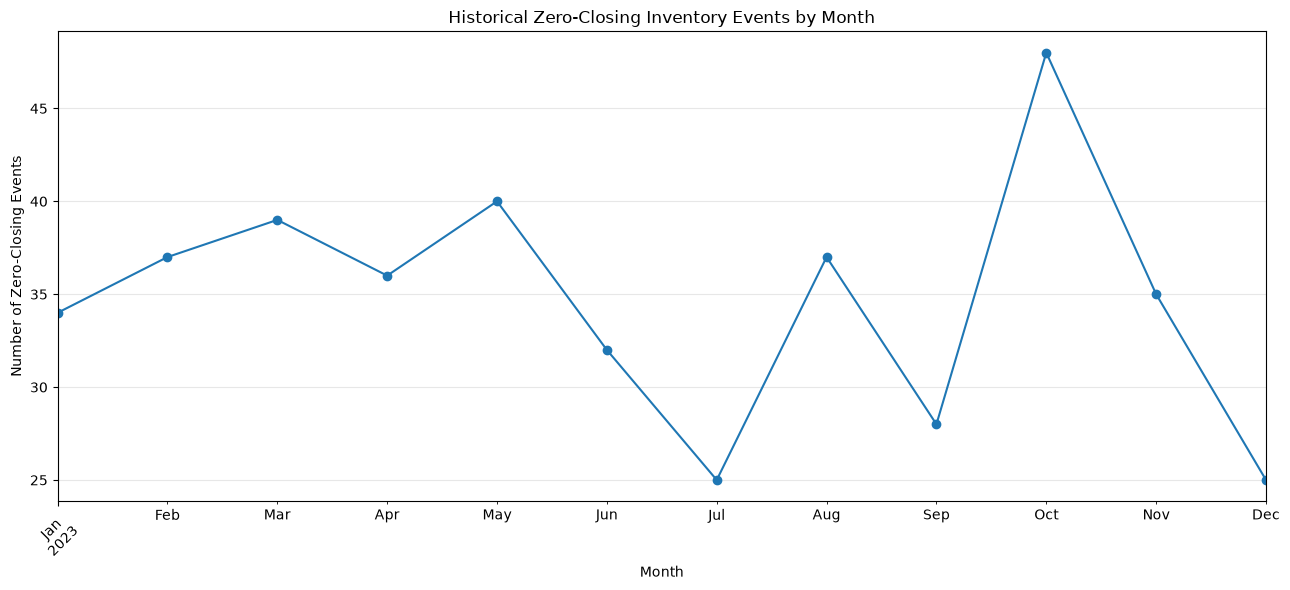

In [146]:
plt.figure(figsize=(13, 6))

monthly_stockouts.plot(
    kind="line",
    marker="o"
)

plt.title("Historical Zero-Closing Inventory Events by Month")
plt.xlabel("Month")
plt.ylabel("Number of Zero-Closing Events")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [147]:
# Create a concise historical stockout summary.

stockout_business_summary = pd.DataFrame({
    "Metric": [
        "Total Zero-Closing Records",
        "Zero-Closing Records with Non-Zero Consumption",
        "Zero-Closing Records with Non-Zero Consumption (%)",
        "Total Consumption on Zero-Closing Records (ml)",
        "Number of Bars with Zero-Closing Events",
        "Number of Brands with Zero-Closing Events",
        "Number of Bar-Brand Combinations with Zero-Closing Events"
    ],
    "Value": [
        len(stockout_df),
        len(stockout_demand_df),
        f"{stockout_demand_percentage:.2f}%",
        f"{stockout_consumption:,.2f}",
        stockout_df["Bar Name"].nunique(),
        stockout_df["Brand Name"].nunique(),
        stockout_summary.shape[0]
    ]
})

stockout_business_summary

,Metric,Value
0,Total Zero-Closing Records,416
1,Zero-Closing Records with Non-Zero Consumption,102
2,Zero-Closing Records with Non-Zero Consumption...,24.52%
3,Total Consumption on Zero-Closing Records (ml),"26,363.84"
4,Number of Bars with Zero-Closing Events,6
5,Number of Brands with Zero-Closing Events,16
6,Number of Bar-Brand Combinations with Zero-Clo...,50


In [148]:
# Save detailed historical stockout analysis.

stockout_output_path = (
    "../data/processed/historical_stockout_analysis.csv"
)

stockout_summary.to_csv(
    stockout_output_path,
    index=False
)

print("Historical stockout analysis saved successfully.")
print("File:", stockout_output_path)

Historical stockout analysis saved successfully.
File: ../data/processed/historical_stockout_analysis.csv


### Historical Stockout Analysis Conclusion

Historical inventory records were examined to identify zero-closing-balance events and cases where zero closing inventory occurred alongside non-zero consumption.

The analysis was performed at Bar, Brand, and Bar-Brand levels to identify recurring inventory depletion patterns.

Stockout event rates were also calculated relative to the number of observed days, providing a more comparable measure across Bar-Brand combinations.

These historical observations will be used as a baseline for evaluating the proposed dynamic par-level and replenishment policy during backtesting.

## Step 15 — Train/Test Split

For demand forecasting, the dataset is divided chronologically into training and testing periods.

- Training data: First 80% of available dates
- Testing data: Last 20% of available dates
- Random train-test splitting is avoided because it can cause future information to leak into the training data.
- The same date cutoff is applied across all Bar-Brand combinations to maintain a consistent forecasting evaluation period.

In [149]:
# Prepare the dataset for forecasting

forecast_df = daily_ts[
    [
        "Date",
        "Bar Name",
        "Brand Name",
        "Alcohol Type",
        "Daily Consumption (ml)"
    ]
].copy()

# Sort chronologically within each Bar-Brand combination
forecast_df = forecast_df.sort_values(
    ["Bar Name", "Brand Name", "Date"]
).reset_index(drop=True)

print("Forecasting dataset prepared successfully.")
print(f"Rows: {len(forecast_df):,}")
print(f"Date range: {forecast_df['Date'].min().date()} to {forecast_df['Date'].max().date()}")
print(f"Unique dates: {forecast_df['Date'].nunique()}")
print(f"Unique Bar-Brand combinations: {forecast_df[['Bar Name', 'Brand Name']].drop_duplicates().shape[0]}")

Forecasting dataset prepared successfully.
Rows: 35,136
Date range: 2023-01-01 to 2024-01-01
Unique dates: 366
Unique Bar-Brand combinations: 96


In [150]:
# Get unique dates in chronological order

unique_dates = (
    forecast_df["Date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

# Calculate 80% training cutoff
split_index = int(len(unique_dates) * 0.80)

train_end_date = unique_dates.iloc[split_index - 1]
test_start_date = unique_dates.iloc[split_index]

print("Chronological split created.")
print(f"Total dates: {len(unique_dates)}")
print(f"Training dates: {split_index}")
print(f"Testing dates: {len(unique_dates) - split_index}")
print(f"Training end date: {train_end_date.date()}")
print(f"Testing start date: {test_start_date.date()}")

Chronological split created.
Total dates: 366
Training dates: 292
Testing dates: 74
Training end date: 2023-10-19
Testing start date: 2023-10-20


In [151]:
# Create chronological training and testing datasets

train_df = forecast_df[
    forecast_df["Date"] <= train_end_date
].copy()

test_df = forecast_df[
    forecast_df["Date"] >= test_start_date
].copy()

print("Train/Test datasets created successfully.")
print(f"Training rows: {len(train_df):,}")
print(f"Testing rows: {len(test_df):,}")

print("\nTraining period:")
print(f"{train_df['Date'].min().date()} to {train_df['Date'].max().date()}")

print("\nTesting period:")
print(f"{test_df['Date'].min().date()} to {test_df['Date'].max().date()}")

Train/Test datasets created successfully.
Training rows: 28,032
Testing rows: 7,104

Training period:
2023-01-01 to 2023-10-19

Testing period:
2023-10-20 to 2024-01-01


In [152]:
# Verify that training data occurs strictly before testing data

assert train_df["Date"].max() < test_df["Date"].min()

print("✓ No temporal data leakage detected.")
print(
    f"Training ends on {train_df['Date'].max().date()} "
    f"and testing starts on {test_df['Date'].min().date()}."
)

✓ No temporal data leakage detected.
Training ends on 2023-10-19 and testing starts on 2023-10-20.


In [153]:
# Create a train-test split summary

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Start Date": [
        train_df["Date"].min(),
        test_df["Date"].min()
    ],
    "End Date": [
        train_df["Date"].max(),
        test_df["Date"].max()
    ],
    "Unique Dates": [
        train_df["Date"].nunique(),
        test_df["Date"].nunique()
    ],
    "Rows": [
        len(train_df),
        len(test_df)
    ]
})

split_summary

,Dataset,Start Date,End Date,Unique Dates,Rows
0,Training,2023-01-01,2023-10-19,292,28032
1,Testing,2023-10-20,2024-01-01,74,7104


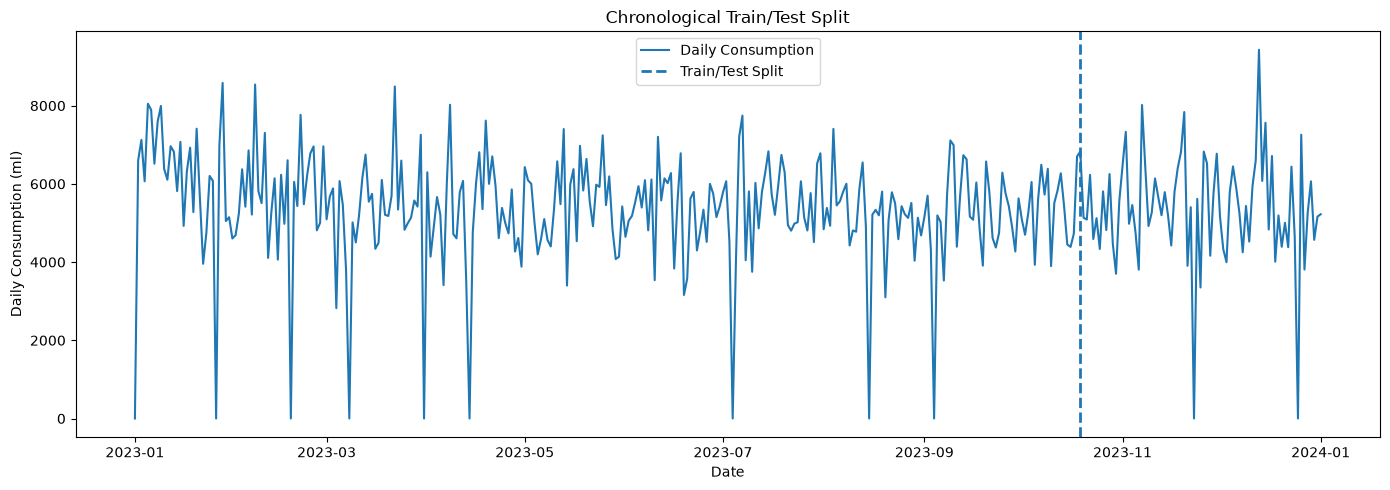

In [154]:
# Aggregate total daily consumption for visualization

overall_daily = (
    forecast_df
    .groupby("Date", as_index=False)["Daily Consumption (ml)"]
    .sum()
)

plt.figure(figsize=(14, 5))

plt.plot(
    overall_daily["Date"],
    overall_daily["Daily Consumption (ml)"],
    label="Daily Consumption"
)

plt.axvline(
    train_end_date,
    linestyle="--",
    linewidth=2,
    label="Train/Test Split"
)

plt.title("Chronological Train/Test Split")
plt.xlabel("Date")
plt.ylabel("Daily Consumption (ml)")
plt.legend()
plt.tight_layout()
plt.show()

In [155]:
# Save train-test split information

split_summary.to_csv(
    "../data/processed/train_test_split_summary.csv",
    index=False
)

print("Train/test split summary saved successfully.")

Train/test split summary saved successfully.


### Step 15 Conclusion

The forecasting dataset was divided chronologically into training and testing periods using an 80/20 date-based split.

The training period contains the earlier historical observations, while the testing period contains the most recent observations. This approach prevents future information from entering the training data and provides a realistic evaluation framework for demand forecasting.

The testing period will be used to compare forecasting models using MAE and WAPE.

## Step 16 — Baseline Forecasting

Before applying advanced forecasting models, baseline forecasting methods are established for comparison.

Two baseline methods are used:

1. **7-Day Rolling Mean**
   - Forecast is based on the average consumption of the previous 7 days.
   - This provides a simple demand-smoothing benchmark.

2. **7-Day Seasonal Naive**
   - Forecast for a day is based on consumption from the same weekday in the previous week.
   - This captures weekly demand patterns and is useful when consumption varies by day of week.

These baseline models will later be compared with Holt-Winters and Machine Learning models using MAE and WAPE.

In [162]:
from sklearn.metrics import mean_absolute_error

def calculate_wape(actual, forecast):
    """
    Calculate Weighted Absolute Percentage Error (WAPE).
    """
    denominator = np.sum(np.abs(actual))
    
    if denominator == 0:
        return np.nan
    
    return np.sum(np.abs(actual - forecast)) / denominator


def evaluate_forecast(actual, forecast):
    """
    Calculate MAE and WAPE for a forecast.
    """
    mae = mean_absolute_error(actual, forecast)
    wape = calculate_wape(actual, forecast)
    
    return mae, wape

In [160]:
# ---------------------------------------------------------
# Baseline 1: 7-Day Rolling Mean
# ---------------------------------------------------------

train_sorted = train_df.sort_values(
    ["Bar Name", "Brand Name", "Date"]
).copy()

last_7_values = (
    train_sorted
    .groupby(["Bar Name", "Brand Name"])
    .tail(7)
)

rolling_mean_baseline = (
    last_7_values
    .groupby(["Bar Name", "Brand Name"])["Daily Consumption (ml)"]
    .mean()
    .reset_index()
    .rename(
        columns={
            "Daily Consumption (ml)": "Rolling Mean Forecast (ml)"
        }
    )
)

baseline_test = test_df.merge(
    rolling_mean_baseline,
    on=["Bar Name", "Brand Name"],
    how="left"
)

print("7-Day Rolling Mean baseline created.")
print(
    baseline_test[
        [
            "Bar Name",
            "Brand Name",
            "Rolling Mean Forecast (ml)"
        ]
    ].head(10)
)

7-Day Rolling Mean baseline created.
         Bar Name Brand Name  Rolling Mean Forecast (ml)
0  Anderson's Bar    Absolut                      118.26
1  Anderson's Bar    Absolut                      118.26
2  Anderson's Bar    Absolut                      118.26
3  Anderson's Bar    Absolut                      118.26
4  Anderson's Bar    Absolut                      118.26
5  Anderson's Bar    Absolut                      118.26
6  Anderson's Bar    Absolut                      118.26
7  Anderson's Bar    Absolut                      118.26
8  Anderson's Bar    Absolut                      118.26
9  Anderson's Bar    Absolut                      118.26


In [163]:
# ---------------------------------------------------------
# Baseline 2: 7-Day Seasonal Naive
# ---------------------------------------------------------

seasonal_df = forecast_df.sort_values(
    ["Bar Name", "Brand Name", "Date"]
).copy()

seasonal_df["Seasonal Naive Forecast (ml)"] = (
    seasonal_df
    .groupby(["Bar Name", "Brand Name"])["Daily Consumption (ml)"]
    .shift(7)
)

seasonal_test = seasonal_df[
    seasonal_df["Date"] >= test_start_date
].copy()

print("7-Day Seasonal Naive baseline created.")

print(
    seasonal_test[
        [
            "Date",
            "Bar Name",
            "Brand Name",
            "Daily Consumption (ml)",
            "Seasonal Naive Forecast (ml)"
        ]
    ].head(10)
)

7-Day Seasonal Naive baseline created.
          Date        Bar Name Brand Name  Daily Consumption (ml)  \
292 2023-10-20  Anderson's Bar    Absolut                    0.00   
293 2023-10-21  Anderson's Bar    Absolut                    0.00   
294 2023-10-22  Anderson's Bar    Absolut                    0.00   
295 2023-10-23  Anderson's Bar    Absolut                    0.00   
296 2023-10-24  Anderson's Bar    Absolut                  174.39   
297 2023-10-25  Anderson's Bar    Absolut                    0.00   
298 2023-10-26  Anderson's Bar    Absolut                    0.00   
299 2023-10-27  Anderson's Bar    Absolut                    0.00   
300 2023-10-28  Anderson's Bar    Absolut                    0.00   
301 2023-10-29  Anderson's Bar    Absolut                    0.00   

     Seasonal Naive Forecast (ml)  
292                          0.00  
293                          0.00  
294                        325.75  
295                          0.00  
296                  

In [164]:
baseline_results = baseline_test.merge(
    seasonal_test[
        [
            "Date",
            "Bar Name",
            "Brand Name",
            "Seasonal Naive Forecast (ml)"
        ]
    ],
    on=["Date", "Bar Name", "Brand Name"],
    how="left"
)

print("Baseline forecasts combined successfully.")

baseline_results.head()

Baseline forecasts combined successfully.


,Date,Bar Name,Brand Name,Alcohol Type,Daily Consumption (ml),Rolling Mean Forecast (ml),Seasonal Naive Forecast (ml)
0,2023-10-20,Anderson's Bar,Absolut,Vodka,0.00,118.26,0.00
1,2023-10-21,Anderson's Bar,Absolut,Vodka,0.00,118.26,0.00
2,2023-10-22,Anderson's Bar,Absolut,Vodka,0.00,118.26,325.75
3,2023-10-23,Anderson's Bar,Absolut,Vodka,0.00,118.26,0.00
4,2023-10-24,Anderson's Bar,Absolut,Vodka,174.39,118.26,0.00


In [165]:
# Check missing values in baseline forecasts

print("Missing 7-Day Rolling Mean forecasts:")
print(
    baseline_results["Rolling Mean Forecast (ml)"]
    .isna()
    .sum()
)

print("\nMissing Seasonal Naive forecasts:")
print(
    baseline_results["Seasonal Naive Forecast (ml)"]
    .isna()
    .sum()
)

Missing 7-Day Rolling Mean forecasts:
0

Missing Seasonal Naive forecasts:
0


In [166]:
# Remove rows where seasonal naive forecast is unavailable
evaluation_df = baseline_results.dropna(
    subset=[
        "Rolling Mean Forecast (ml)",
        "Seasonal Naive Forecast (ml)"
    ]
).copy()

actual = evaluation_df["Daily Consumption (ml)"]

rolling_mae, rolling_wape = evaluate_forecast(
    actual,
    evaluation_df["Rolling Mean Forecast (ml)"]
)

seasonal_mae, seasonal_wape = evaluate_forecast(
    actual,
    evaluation_df["Seasonal Naive Forecast (ml)"]
)

baseline_metrics = pd.DataFrame({
    "Model": [
        "7-Day Rolling Mean",
        "7-Day Seasonal Naive"
    ],
    "MAE (ml)": [
        rolling_mae,
        seasonal_mae
    ],
    "WAPE": [
        rolling_wape,
        seasonal_wape
    ]
})

baseline_metrics["WAPE (%)"] = (
    baseline_metrics["WAPE"] * 100
)

baseline_metrics = baseline_metrics.drop(
    columns=["WAPE"]
)

baseline_metrics

,Model,MAE (ml),WAPE (%)
0,7-Day Rolling Mean,94.44,169.52
1,7-Day Seasonal Naive,97.53,175.06


## Step 17 — Holt-Winters Exponential Smoothing

Holt-Winters Exponential Smoothing is used to capture level, trend, and weekly seasonality in daily consumption.

A separate model is fitted for each Bar-Brand combination using the chronological training data.

Model configuration:

- Trend: Additive
- Seasonality: Additive
- Seasonal period: 7 days
- Forecast horizon: Complete testing period

The model performance will be evaluated using MAE and WAPE.

In [167]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [168]:
# ---------------------------------------------------------
# Holt-Winters Forecasting
# ---------------------------------------------------------

hw_forecasts = []

group_columns = ["Bar Name", "Brand Name"]

for (bar, brand), group in forecast_df.groupby(group_columns):

    group = group.sort_values("Date").copy()

    train_series = group[
        group["Date"] <= train_end_date
    ]["Daily Consumption (ml)"]

    test_group = group[
        group["Date"] >= test_start_date
    ].copy()

    if len(train_series) < 14:
        print(f"Skipping {bar} - {brand}: insufficient training data")
        continue

    try:
        model = ExponentialSmoothing(
            train_series,
            trend="add",
            seasonal="add",
            seasonal_periods=7,
            initialization_method="estimated"
        )

        fitted_model = model.fit(
            optimized=True
        )

        forecast_values = fitted_model.forecast(
            len(test_group)
        )

        # Demand cannot be negative
        forecast_values = np.maximum(
            forecast_values,
            0
        )

        test_group["Holt-Winters Forecast (ml)"] = forecast_values.values

        hw_forecasts.append(
            test_group[
                [
                    "Date",
                    "Bar Name",
                    "Brand Name",
                    "Daily Consumption (ml)",
                    "Holt-Winters Forecast (ml)"
                ]
            ]
        )

    except Exception as e:
        print(
            f"Model failed for {bar} - {brand}: {str(e)}"
        )

hw_forecast_df = pd.concat(
    hw_forecasts,
    ignore_index=True
)

print("Holt-Winters forecasting completed.")
print(f"Forecast rows: {len(hw_forecast_df):,}")

Holt-Winters forecasting completed.
Forecast rows: 7,104


In [170]:
# Check missing values

print(
    "Missing Holt-Winters forecasts:",
    hw_forecast_df["Holt-Winters Forecast (ml)"].isna().sum()
)

print("\nNegative forecasts:")
print(
    (
        hw_forecast_df["Holt-Winters Forecast (ml)"] < 0
    ).sum()
)

hw_forecast_df.head(10)

Missing Holt-Winters forecasts: 0

Negative forecasts:
0


,Date,Bar Name,Brand Name,Daily Consumption (ml),Holt-Winters Forecast (ml)
0,2023-10-20,Anderson's Bar,Absolut,0.00,25.36
1,2023-10-21,Anderson's Bar,Absolut,0.00,0.00
2,2023-10-22,Anderson's Bar,Absolut,0.00,30.94
3,2023-10-23,Anderson's Bar,Absolut,0.00,1.33
4,2023-10-24,Anderson's Bar,Absolut,174.39,25.23
5,2023-10-25,Anderson's Bar,Absolut,0.00,13.00
6,2023-10-26,Anderson's Bar,Absolut,0.00,71.11
7,2023-10-27,Anderson's Bar,Absolut,0.00,24.95
8,2023-10-28,Anderson's Bar,Absolut,0.00,0.00
9,2023-10-29,Anderson's Bar,Absolut,0.00,30.53


In [171]:
# ---------------------------------------------------------
# Evaluate Holt-Winters
# ---------------------------------------------------------

hw_actual = hw_forecast_df["Daily Consumption (ml)"]
hw_predicted = hw_forecast_df["Holt-Winters Forecast (ml)"]

hw_mae, hw_wape = evaluate_forecast(
    hw_actual,
    hw_predicted
)

hw_metrics = pd.DataFrame({
    "Model": ["Holt-Winters"],
    "MAE (ml)": [hw_mae],
    "WAPE (%)": [hw_wape * 100]
})

hw_metrics

,Model,MAE (ml),WAPE (%)
0,Holt-Winters,91.91,164.97


In [172]:
# Combine baseline and Holt-Winters metrics

all_model_metrics = pd.concat(
    [
        baseline_metrics,
        hw_metrics
    ],
    ignore_index=True
)

all_model_metrics

,Model,MAE (ml),WAPE (%)
0,7-Day Rolling Mean,94.44,169.52
1,7-Day Seasonal Naive,97.53,175.06
2,Holt-Winters,91.91,164.97


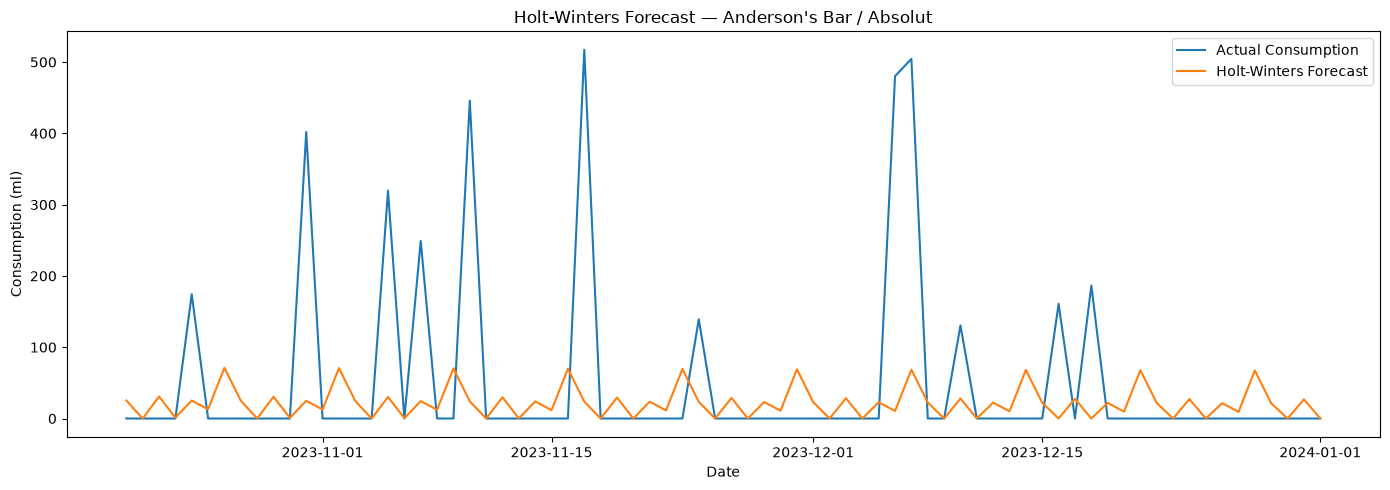

In [173]:
# Select the first available Bar-Brand combination

sample_bar = hw_forecast_df["Bar Name"].iloc[0]
sample_brand = hw_forecast_df["Brand Name"].iloc[0]

sample_hw = hw_forecast_df[
    (hw_forecast_df["Bar Name"] == sample_bar) &
    (hw_forecast_df["Brand Name"] == sample_brand)
]

plt.figure(figsize=(14, 5))

plt.plot(
    sample_hw["Date"],
    sample_hw["Daily Consumption (ml)"],
    label="Actual Consumption"
)

plt.plot(
    sample_hw["Date"],
    sample_hw["Holt-Winters Forecast (ml)"],
    label="Holt-Winters Forecast"
)

plt.title(
    f"Holt-Winters Forecast — {sample_bar} / {sample_brand}"
)

plt.xlabel("Date")
plt.ylabel("Consumption (ml)")
plt.legend()
plt.tight_layout()
plt.show()

### Step 17 Conclusion

Holt-Winters Exponential Smoothing was applied separately to each Bar-Brand time series using additive trend and 7-day seasonality.

The model forecasts were evaluated on the chronological test period using MAE and WAPE.

The Holt-Winters results will be compared with the baseline models and the upcoming Machine Learning model before selecting the forecasting approach for inventory planning.

## Step 18 — Machine Learning Forecasting with Random Forest

A Random Forest Regressor is used as a machine learning forecasting model.

The model uses historical demand and calendar-based features:

- Lag 1 day
- Lag 7 days
- Lag 14 days
- 7-day rolling mean
- 7-day rolling standard deviation
- Day of week
- Weekend indicator
- Month

All lag and rolling features are constructed using previous observations only to avoid target leakage.

The model is trained using the chronological training period and evaluated on the chronological testing period.

In [174]:
# ---------------------------------------------------------
# Create Machine Learning Features
# ---------------------------------------------------------

ml_df = forecast_df.sort_values(
    ["Bar Name", "Brand Name", "Date"]
).copy()

group_cols = ["Bar Name", "Brand Name"]

# Lag features
ml_df["Lag 1"] = (
    ml_df.groupby(group_cols)["Daily Consumption (ml)"]
    .shift(1)
)

ml_df["Lag 7"] = (
    ml_df.groupby(group_cols)["Daily Consumption (ml)"]
    .shift(7)
)

ml_df["Lag 14"] = (
    ml_df.groupby(group_cols)["Daily Consumption (ml)"]
    .shift(14)
)

# Rolling features based only on previous observations
ml_df["Rolling Mean 7"] = (
    ml_df.groupby(group_cols)["Daily Consumption (ml)"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

ml_df["Rolling Std 7"] = (
    ml_df.groupby(group_cols)["Daily Consumption (ml)"]
    .transform(
        lambda x: x.shift(1).rolling(7).std()
    )
)

# Calendar features
ml_df["Day of Week"] = ml_df["Date"].dt.dayofweek
ml_df["Is Weekend"] = (
    ml_df["Day of Week"] >= 5
).astype(int)

ml_df["Month"] = ml_df["Date"].dt.month

print("ML features created successfully.")

ML features created successfully.


In [175]:
feature_columns = [
    "Lag 1",
    "Lag 7",
    "Lag 14",
    "Rolling Mean 7",
    "Rolling Std 7",
    "Day of Week",
    "Is Weekend",
    "Month"
]

target_column = "Daily Consumption (ml)"

ml_model_df = ml_df.dropna(
    subset=feature_columns + [target_column]
).copy()

print("Rows available for ML modeling:", len(ml_model_df))
print("Missing feature values:")
print(
    ml_model_df[feature_columns]
    .isna()
    .sum()
)

Rows available for ML modeling: 33792
Missing feature values:
Lag 1             0
Lag 7             0
Lag 14            0
Rolling Mean 7    0
Rolling Std 7     0
Day of Week       0
Is Weekend        0
Month             0
dtype: int64


In [176]:
ml_train = ml_model_df[
    ml_model_df["Date"] <= train_end_date
].copy()

ml_test = ml_model_df[
    ml_model_df["Date"] >= test_start_date
].copy()

X_train = ml_train[feature_columns]
y_train = ml_train[target_column]

X_test = ml_test[feature_columns]
y_test = ml_test[target_column]

print("ML training rows:", len(X_train))
print("ML testing rows:", len(X_test))

ML training rows: 26688
ML testing rows: 7104


In [177]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [178]:
rf_predictions = rf_model.predict(X_test)

# Demand cannot be negative
rf_predictions = np.maximum(
    rf_predictions,
    0
)

ml_test["Random Forest Forecast (ml)"] = rf_predictions

print("Random Forest predictions generated.")
print(
    ml_test[
        [
            "Date",
            "Bar Name",
            "Brand Name",
            "Daily Consumption (ml)",
            "Random Forest Forecast (ml)"
        ]
    ].head(10)
)

Random Forest predictions generated.
          Date        Bar Name Brand Name  Daily Consumption (ml)  \
292 2023-10-20  Anderson's Bar    Absolut                    0.00   
293 2023-10-21  Anderson's Bar    Absolut                    0.00   
294 2023-10-22  Anderson's Bar    Absolut                    0.00   
295 2023-10-23  Anderson's Bar    Absolut                    0.00   
296 2023-10-24  Anderson's Bar    Absolut                  174.39   
297 2023-10-25  Anderson's Bar    Absolut                    0.00   
298 2023-10-26  Anderson's Bar    Absolut                    0.00   
299 2023-10-27  Anderson's Bar    Absolut                    0.00   
300 2023-10-28  Anderson's Bar    Absolut                    0.00   
301 2023-10-29  Anderson's Bar    Absolut                    0.00   

     Random Forest Forecast (ml)  
292                        55.38  
293                        55.67  
294                        52.80  
295                        55.76  
296                        5

In [179]:
rf_mae, rf_wape = evaluate_forecast(
    y_test,
    rf_predictions
)

rf_metrics = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE (ml)": [rf_mae],
    "WAPE (%)": [rf_wape * 100]
})

rf_metrics

,Model,MAE (ml),WAPE (%)
0,Random Forest,95.02,170.56


In [180]:
all_model_metrics = pd.concat(
    [
        baseline_metrics,
        hw_metrics,
        rf_metrics
    ],
    ignore_index=True
)

all_model_metrics

,Model,MAE (ml),WAPE (%)
0,7-Day Rolling Mean,94.44,169.52
1,7-Day Seasonal Naive,97.53,175.06
2,Holt-Winters,91.91,164.97
3,Random Forest,95.02,170.56


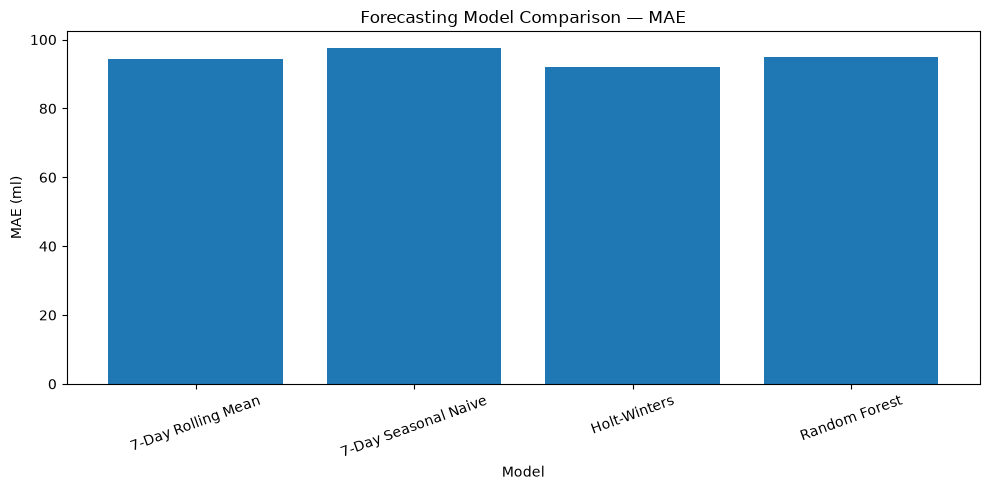

In [181]:
plt.figure(figsize=(10, 5))

plt.bar(
    all_model_metrics["Model"],
    all_model_metrics["MAE (ml)"]
)

plt.title("Forecasting Model Comparison — MAE")
plt.xlabel("Model")
plt.ylabel("MAE (ml)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [182]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Lag 14,0.24
3,Rolling Mean 7,0.18
4,Rolling Std 7,0.18
7,Month,0.11
5,Day of Week,0.10
0,Lag 1,0.09
1,Lag 7,0.08
6,Is Weekend,0.01


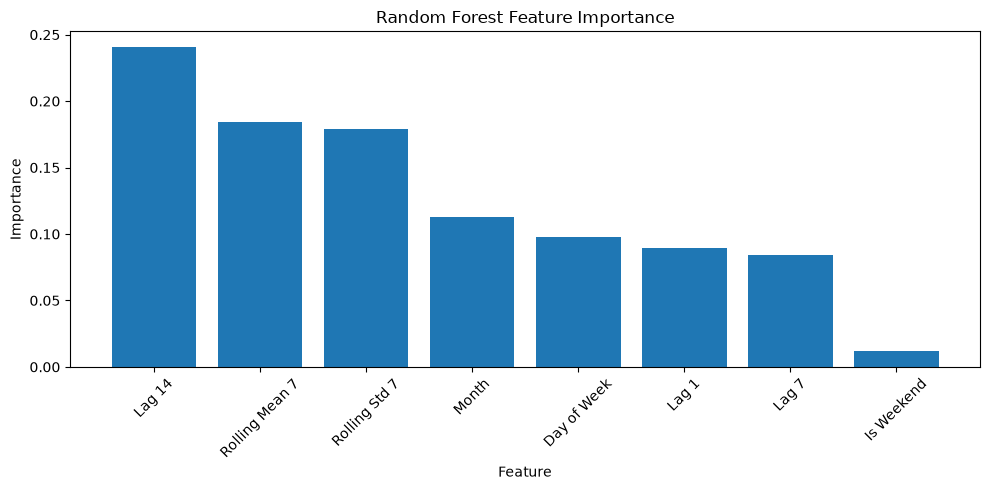

In [183]:
plt.figure(figsize=(10, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 18 Conclusion

A Random Forest regression model was developed using historical demand, lag features, rolling statistics, and calendar features.

The model was trained only on the chronological training period and evaluated on the unseen testing period.

Its MAE and WAPE will be compared with the baseline and Holt-Winters models. Feature importance is also examined to understand which historical demand and calendar variables contribute most to the predictions.

In [184]:
# ---------------------------------------------------------
# Inventory Planning Parameters
# ---------------------------------------------------------

LEAD_TIME_DAYS = 2
SERVICE_LEVEL = 0.95
Z_SCORE = 1.645

print(f"Lead Time: {LEAD_TIME_DAYS} days")
print(f"Service Level: {SERVICE_LEVEL * 100:.0f}%")
print(f"Z-Score: {Z_SCORE}")

Lead Time: 2 days
Service Level: 95%
Z-Score: 1.645


In [185]:
SELECTED_MODEL = "Random Forest"

In [186]:
SELECTED_MODEL = "Holt-Winters"

In [187]:
# Select the model with the lowest MAE

best_model_name = (
    all_model_metrics
    .sort_values("MAE (ml)")
    .iloc[0]["Model"]
)

print("Model with lowest MAE:", best_model_name)

Model with lowest MAE: Holt-Winters


In [188]:
# ---------------------------------------------------------
# Calculate forecast error for the selected model
# ---------------------------------------------------------

if best_model_name == "Random Forest":

    selected_actual = ml_test["Daily Consumption (ml)"]
    selected_forecast = ml_test["Random Forest Forecast (ml)"]

elif best_model_name == "Holt-Winters":

    selected_actual = hw_forecast_df["Daily Consumption (ml)"]
    selected_forecast = hw_forecast_df["Holt-Winters Forecast (ml)"]

elif best_model_name == "7-Day Rolling Mean":

    selected_actual = evaluation_df["Daily Consumption (ml)"]
    selected_forecast = evaluation_df["Rolling Mean Forecast (ml)"]

elif best_model_name == "7-Day Seasonal Naive":

    selected_actual = evaluation_df["Daily Consumption (ml)"]
    selected_forecast = evaluation_df["Seasonal Naive Forecast (ml)"]

else:
    raise ValueError("Unknown forecasting model")

forecast_errors = (
    selected_actual.values - selected_forecast.values
)

rmse = np.sqrt(
    np.mean(forecast_errors ** 2)
)

print(f"Selected Model: {best_model_name}")
print(f"Forecast RMSE: {rmse:.2f} ml")  

Selected Model: Holt-Winters
Forecast RMSE: 147.12 ml


In [189]:
# ---------------------------------------------------------
# Calculate Bar-Brand specific RMSE
# ---------------------------------------------------------

if best_model_name == "Random Forest":

    error_df = ml_test[
        [
            "Bar Name",
            "Brand Name",
            "Daily Consumption (ml)",
            "Random Forest Forecast (ml)"
        ]
    ].copy()

    error_df["Forecast Error"] = (
        error_df["Daily Consumption (ml)"]
        - error_df["Random Forest Forecast (ml)"]
    )

elif best_model_name == "Holt-Winters":

    error_df = hw_forecast_df[
        [
            "Bar Name",
            "Brand Name",
            "Daily Consumption (ml)",
            "Holt-Winters Forecast (ml)"
        ]
    ].copy()

    error_df["Forecast Error"] = (
        error_df["Daily Consumption (ml)"]
        - error_df["Holt-Winters Forecast (ml)"]
    )

else:
    raise ValueError(
        "For this par-level calculation, use Holt-Winters or Random Forest."
    )


rmse_by_series = (
    error_df
    .groupby(["Bar Name", "Brand Name"])["Forecast Error"]
    .apply(lambda x: np.sqrt(np.mean(x ** 2)))
    .reset_index(name="Forecast RMSE (ml)")
)

rmse_by_series.head()

,Bar Name,Brand Name,Forecast RMSE (ml)
0,Anderson's Bar,Absolut,131.26
1,Anderson's Bar,Bacardi,154.69
2,Anderson's Bar,Barefoot,148.52
3,Anderson's Bar,Budweiser,52.68
4,Anderson's Bar,Captain Morgan,141.30


In [190]:
# ---------------------------------------------------------
# Average Forecasted Daily Demand
# ---------------------------------------------------------

if best_model_name == "Random Forest":

    forecast_demand_by_series = (
        ml_test
        .groupby(["Bar Name", "Brand Name"])
        ["Random Forest Forecast (ml)"]
        .mean()
        .reset_index()
        .rename(
            columns={
                "Random Forest Forecast (ml)":
                "Forecasted Daily Demand (ml)"
            }
        )
    )

elif best_model_name == "Holt-Winters":

    forecast_demand_by_series = (
        hw_forecast_df
        .groupby(["Bar Name", "Brand Name"])
        ["Holt-Winters Forecast (ml)"]
        .mean()
        .reset_index()
        .rename(
            columns={
                "Holt-Winters Forecast (ml)":
                "Forecasted Daily Demand (ml)"
            }
        )
    )

forecast_demand_by_series.head()

,Bar Name,Brand Name,Forecasted Daily Demand (ml)
0,Anderson's Bar,Absolut,21.82
1,Anderson's Bar,Bacardi,66.60
2,Anderson's Bar,Barefoot,109.64
3,Anderson's Bar,Budweiser,46.67
4,Anderson's Bar,Captain Morgan,88.69


In [191]:
# ---------------------------------------------------------
# Calculate Safety Stock
# ---------------------------------------------------------

par_level_df = forecast_demand_by_series.merge(
    rmse_by_series,
    on=["Bar Name", "Brand Name"],
    how="left"
)

par_level_df["Safety Stock (ml)"] = (
    Z_SCORE
    * par_level_df["Forecast RMSE (ml)"]
    * np.sqrt(LEAD_TIME_DAYS)
)

par_level_df.head()

,Bar Name,Brand Name,Forecasted Daily Demand (ml),Forecast RMSE (ml),Safety Stock (ml)
0,Anderson's Bar,Absolut,21.82,131.26,305.36
1,Anderson's Bar,Bacardi,66.60,154.69,359.88
2,Anderson's Bar,Barefoot,109.64,148.52,345.52
3,Anderson's Bar,Budweiser,46.67,52.68,122.55
4,Anderson's Bar,Captain Morgan,88.69,141.30,328.71


In [192]:
# ---------------------------------------------------------
# Dynamic Par Level
# ---------------------------------------------------------

par_level_df["Lead Time Demand (ml)"] = (
    par_level_df["Forecasted Daily Demand (ml)"]
    * LEAD_TIME_DAYS
)

par_level_df["Dynamic Par Level (ml)"] = (
    par_level_df["Lead Time Demand (ml)"]
    + par_level_df["Safety Stock (ml)"]
)

par_level_df["Dynamic Par Level (ml)"] = (
    par_level_df["Dynamic Par Level (ml)"]
    .clip(lower=0)
)

par_level_df = par_level_df.sort_values(
    "Dynamic Par Level (ml)",
    ascending=False
).reset_index(drop=True)

par_level_df.head(20)

,Bar Name,Brand Name,Forecasted Daily Demand (ml),Forecast RMSE (ml),Safety Stock (ml),Lead Time Demand (ml),Dynamic Par Level (ml)
0,Brown's Bar,Yellow Tail,100.43,192.91,448.78,200.87,649.64
1,Taylor's Bar,Grey Goose,104.20,171.15,398.16,208.40,606.56
2,Brown's Bar,Grey Goose,69.00,199.68,464.53,138.01,602.53
3,Brown's Bar,Jameson,66.06,194.72,452.99,132.13,585.12
4,Thomas's Bar,Bacardi,72.54,185.89,432.46,145.07,577.53
5,Brown's Bar,Jim Beam,76.69,180.61,420.17,153.39,573.56
6,Anderson's Bar,Barefoot,109.64,148.52,345.52,219.28,564.80
7,Anderson's Bar,Smirnoff,69.66,180.26,419.35,139.32,558.67
8,Anderson's Bar,Jim Beam,53.91,193.62,450.43,107.82,558.25
9,Taylor's Bar,Jim Beam,50.65,196.16,456.33,101.30,557.64


In [193]:
par_level_df["Par Level (Litres)"] = (
    par_level_df["Dynamic Par Level (ml)"] / 1000
)

par_level_df[
    [
        "Bar Name",
        "Brand Name",
        "Forecasted Daily Demand (ml)",
        "Lead Time Demand (ml)",
        "Forecast RMSE (ml)",
        "Safety Stock (ml)",
        "Dynamic Par Level (ml)",
        "Par Level (Litres)"
    ]
].head(20)

,Bar Name,Brand Name,Forecasted Daily Demand (ml),Lead Time Demand (ml),Forecast RMSE (ml),Safety Stock (ml),Dynamic Par Level (ml),Par Level (Litres)
0,Brown's Bar,Yellow Tail,100.43,200.87,192.91,448.78,649.64,0.65
1,Taylor's Bar,Grey Goose,104.20,208.40,171.15,398.16,606.56,0.61
2,Brown's Bar,Grey Goose,69.00,138.01,199.68,464.53,602.53,0.60
3,Brown's Bar,Jameson,66.06,132.13,194.72,452.99,585.12,0.59
4,Thomas's Bar,Bacardi,72.54,145.07,185.89,432.46,577.53,0.58
5,Brown's Bar,Jim Beam,76.69,153.39,180.61,420.17,573.56,0.57
6,Anderson's Bar,Barefoot,109.64,219.28,148.52,345.52,564.80,0.56
7,Anderson's Bar,Smirnoff,69.66,139.32,180.26,419.35,558.67,0.56
8,Anderson's Bar,Jim Beam,53.91,107.82,193.62,450.43,558.25,0.56
9,Taylor's Bar,Jim Beam,50.65,101.30,196.16,456.33,557.64,0.56


In [194]:
# Save dynamic par-level recommendations

par_level_df.to_csv(
    "../data/processed/dynamic_par_level_recommendations.csv",
    index=False
)

print(
    "Dynamic par-level recommendations saved successfully."
)

Dynamic par-level recommendations saved successfully.


In [195]:
print("========== DYNAMIC PAR LEVEL SUMMARY ==========")
print(f"Selected Model: {best_model_name}")
print(f"Lead Time: {LEAD_TIME_DAYS} days")
print(f"Service Level: {SERVICE_LEVEL * 100:.0f}%")
print(f"Number of Bar-Brand combinations: {len(par_level_df):,}")

print(
    f"\nAverage Par Level: "
    f"{par_level_df['Dynamic Par Level (ml)'].mean():,.2f} ml"
)

print(
    f"Maximum Par Level: "
    f"{par_level_df['Dynamic Par Level (ml)'].max():,.2f} ml"
)

print(
    f"Minimum Par Level: "
    f"{par_level_df['Dynamic Par Level (ml)'].min():,.2f} ml"
)

========== DYNAMIC PAR LEVEL SUMMARY ==========
Selected Model: Holt-Winters
Lead Time: 2 days
Service Level: 95%
Number of Bar-Brand combinations: 96

Average Par Level: 442.41 ml
Maximum Par Level: 649.64 ml
Minimum Par Level: 215.89 ml


### Step 19 Conclusion

Dynamic inventory par levels were calculated for each Bar-Brand combination using the selected forecasting model.

The recommended par level combines expected demand during the 2-day lead time with safety stock based on forecast uncertainty.

A 95% service-level target was used to determine the safety-stock multiplier.

These recommendations provide an inventory target that can be used to support replenishment decisions while accounting for both expected demand and demand uncertainty.

## Step 20 — Inventory Policy Simulation / Backtesting

The recommended dynamic par levels are evaluated through an inventory simulation over the test period.

The simulation follows an order-up-to inventory policy:

1. Daily demand is deducted from available inventory.
2. Outstanding purchase orders are received after the specified lead time.
3. If inventory position falls below the reorder point, a replenishment order is placed.
4. The replenishment quantity brings inventory position toward the recommended par level.
5. Stockouts, lost volume, inventory levels, and replenishment activity are recorded.

The simulation uses actual test-period consumption to evaluate how the recommended inventory policy would have performed historically.

In [197]:
# ---------------------------------------------------------
# Prepare inventory simulation data
# ---------------------------------------------------------

simulation_df = test_df.copy()

simulation_df = simulation_df.sort_values(
    ["Bar Name", "Brand Name", "Date"]
).reset_index(drop=True)

# Get opening inventory on the first test day
initial_inventory = (
    df[df["Date Time Served"].dt.floor("D") == test_start_date]
    .groupby(["Bar Name", "Brand Name"])["Opening Balance (ml)"]
    .first()
    .reset_index()
    .rename(
        columns={
            "Opening Balance (ml)": "Initial Inventory (ml)"
        }
    )
)

simulation_df = simulation_df.merge(
    initial_inventory,
    on=["Bar Name", "Brand Name"],
    how="left"
)

# Add recommended par levels
simulation_df = simulation_df.merge(
    par_level_df[
        [
            "Bar Name",
            "Brand Name",
            "Dynamic Par Level (ml)"
        ]
    ],
    on=["Bar Name", "Brand Name"],
    how="left"
)

print("Simulation dataset prepared.")
print(f"Rows: {len(simulation_df):,}")

Simulation dataset prepared.
Rows: 7,104


In [198]:
# ---------------------------------------------------------
# Inventory Policy Simulation Function
# ---------------------------------------------------------

def simulate_inventory_policy(
    series_df,
    initial_inventory,
    par_level,
    lead_time_days
):
    """
    Simulate an order-up-to inventory policy.

    Reorder point = Dynamic Par Level.
    Orders arrive after the specified lead time.
    """

    data = series_df.sort_values("Date").copy()

    inventory = float(initial_inventory)

    pending_orders = {}

    results = []

    for _, row in data.iterrows():

        current_date = row["Date"]
        demand = float(row["Daily Consumption (ml)"])

        # Receive orders scheduled for today
        arrivals = pending_orders.pop(current_date, 0)

        inventory += arrivals

        beginning_inventory = inventory

        # Actual consumption
        available_for_demand = min(
            inventory,
            demand
        )

        lost_volume = max(
            0,
            demand - inventory
        )

        inventory = max(
            0,
            inventory - demand
        )

        # Inventory position includes outstanding orders
        outstanding_inventory = sum(
            pending_orders.values()
        )

        inventory_position = (
            inventory + outstanding_inventory
        )

        order_quantity = 0

        # Order up to par level
        if inventory_position < par_level:

            order_quantity = max(
                0,
                par_level - inventory_position
            )

            arrival_date = (
                current_date
                + pd.Timedelta(days=lead_time_days)
            )

            pending_orders[arrival_date] = (
                pending_orders.get(arrival_date, 0)
                + order_quantity
            )

        results.append({
            "Date": current_date,
            "Beginning Inventory (ml)": beginning_inventory,
            "Demand (ml)": demand,
            "Arrivals (ml)": arrivals,
            "Ending Inventory (ml)": inventory,
            "Lost Volume (ml)": lost_volume,
            "Order Quantity (ml)": order_quantity,
            "Outstanding Inventory (ml)": outstanding_inventory,
            "Inventory Position (ml)": inventory_position
        })

    return pd.DataFrame(results)

In [199]:
# ---------------------------------------------------------
# Run simulation for every Bar-Brand combination
# ---------------------------------------------------------

simulation_results = []

for (bar, brand), group in simulation_df.groupby(
    ["Bar Name", "Brand Name"]
):

    initial_inv = group["Initial Inventory (ml)"].iloc[0]
    par_level = group["Dynamic Par Level (ml)"].iloc[0]

    if pd.isna(initial_inv) or pd.isna(par_level):
        continue

    result = simulate_inventory_policy(
        series_df=group,
        initial_inventory=initial_inv,
        par_level=par_level,
        lead_time_days=LEAD_TIME_DAYS
    )

    result["Bar Name"] = bar
    result["Brand Name"] = brand
    result["Par Level (ml)"] = par_level

    simulation_results.append(result)

inventory_simulation = pd.concat(
    simulation_results,
    ignore_index=True
)

print("Inventory simulation completed.")
print(f"Simulation rows: {len(inventory_simulation):,}")

Inventory simulation completed.
Simulation rows: 1,184


In [200]:
# ---------------------------------------------------------
# Calculate stockout metrics
# ---------------------------------------------------------

inventory_simulation["Stockout"] = (
    inventory_simulation["Ending Inventory (ml)"] <= 0
)

stockout_summary = (
    inventory_simulation
    .groupby(["Bar Name", "Brand Name"])
    .agg(
        Total_Demand_ml=("Demand (ml)", "sum"),
        Stockout_Days=("Stockout", "sum"),
        Lost_Volume_ml=("Lost Volume (ml)", "sum"),
        Average_Inventory_ml=("Ending Inventory (ml)", "mean"),
        Total_Orders=("Order Quantity (ml)", lambda x: (x > 0).sum()),
        Total_Ordered_ml=("Order Quantity (ml)", "sum")
    )
    .reset_index()
)

stockout_summary["Stockout Rate (%)"] = (
    stockout_summary["Stockout_Days"]
    / inventory_simulation.groupby(
        ["Bar Name", "Brand Name"]
    ).size().values
    * 100
)

stockout_summary.head(20)

,Bar Name,Brand Name,Total_Demand_ml,Stockout_Days,Lost_Volume_ml,Average_Inventory_ml,Total_Orders,Total_Ordered_ml,Stockout Rate (%)
0,Anderson's Bar,Barefoot,"4,204.69",0,0.00,"2,405.98",2,148.82,0.00
1,Anderson's Bar,Captain Morgan,"5,186.27",0,0.00,"6,088.07",0,0.00,0.00
2,Brown's Bar,Grey Goose,"6,403.66",0,0.00,"1,868.19",6,"1,948.87",0.00
3,Brown's Bar,Jameson,"6,536.21",0,0.00,"3,414.99",1,138.41,0.00
4,Johnson's Bar,Absolut,"4,546.96",0,0.00,"2,239.53",1,249.29,0.00
5,Johnson's Bar,Malibu,"6,299.14",1,13.27,"2,877.69",3,779.60,1.35
6,Johnson's Bar,Miller,"4,645.79",9,548.05,304.76,13,"3,941.86",12.16
7,Smith's Bar,Absolut,"5,193.59",3,142.22,568.96,14,"3,546.81",4.05
8,Smith's Bar,Sutter Home,"6,651.48",0,0.00,"3,565.31",0,0.00,0.00
9,Taylor's Bar,Absolut,"3,834.04",5,623.70,413.17,9,"2,609.63",6.76


In [201]:
# ---------------------------------------------------------
# Correct stockout rate calculation
# ---------------------------------------------------------

days_by_series = (
    inventory_simulation
    .groupby(["Bar Name", "Brand Name"])
    .size()
    .reset_index(name="Simulation Days")
)

stockout_summary = stockout_summary.drop(
    columns=["Stockout Rate (%)"],
    errors="ignore"
)

stockout_summary = stockout_summary.merge(
    days_by_series,
    on=["Bar Name", "Brand Name"],
    how="left"
)

stockout_summary["Stockout Rate (%)"] = (
    stockout_summary["Stockout_Days"]
    / stockout_summary["Simulation Days"]
    * 100
)

stockout_summary.head(20)

,Bar Name,Brand Name,Total_Demand_ml,Stockout_Days,Lost_Volume_ml,Average_Inventory_ml,Total_Orders,Total_Ordered_ml,Simulation Days,Stockout Rate (%)
0,Anderson's Bar,Barefoot,"4,204.69",0,0.00,"2,405.98",2,148.82,74,0.00
1,Anderson's Bar,Captain Morgan,"5,186.27",0,0.00,"6,088.07",0,0.00,74,0.00
2,Brown's Bar,Grey Goose,"6,403.66",0,0.00,"1,868.19",6,"1,948.87",74,0.00
3,Brown's Bar,Jameson,"6,536.21",0,0.00,"3,414.99",1,138.41,74,0.00
4,Johnson's Bar,Absolut,"4,546.96",0,0.00,"2,239.53",1,249.29,74,0.00
5,Johnson's Bar,Malibu,"6,299.14",1,13.27,"2,877.69",3,779.60,74,1.35
6,Johnson's Bar,Miller,"4,645.79",9,548.05,304.76,13,"3,941.86",74,12.16
7,Smith's Bar,Absolut,"5,193.59",3,142.22,568.96,14,"3,546.81",74,4.05
8,Smith's Bar,Sutter Home,"6,651.48",0,0.00,"3,565.31",0,0.00,74,0.00
9,Taylor's Bar,Absolut,"3,834.04",5,623.70,413.17,9,"2,609.63",74,6.76


In [202]:
# ---------------------------------------------------------
# Inventory Turnover
# ---------------------------------------------------------

stockout_summary["Inventory Turnover"] = (
    stockout_summary["Total_Demand_ml"]
    / stockout_summary["Average_Inventory_ml"].replace(
        0,
        np.nan
    )
)

stockout_summary

,Bar Name,Brand Name,Total_Demand_ml,Stockout_Days,Lost_Volume_ml,Average_Inventory_ml,Total_Orders,Total_Ordered_ml,Simulation Days,Stockout Rate (%),Inventory Turnover
0,Anderson's Bar,Barefoot,"4,204.69",0,0.00,"2,405.98",2,148.82,74,0.00,1.75
1,Anderson's Bar,Captain Morgan,"5,186.27",0,0.00,"6,088.07",0,0.00,74,0.00,0.85
2,Brown's Bar,Grey Goose,"6,403.66",0,0.00,"1,868.19",6,"1,948.87",74,0.00,3.43
3,Brown's Bar,Jameson,"6,536.21",0,0.00,"3,414.99",1,138.41,74,0.00,1.91
4,Johnson's Bar,Absolut,"4,546.96",0,0.00,"2,239.53",1,249.29,74,0.00,2.03
5,Johnson's Bar,Malibu,"6,299.14",1,13.27,"2,877.69",3,779.60,74,1.35,2.19
6,Johnson's Bar,Miller,"4,645.79",9,548.05,304.76,13,"3,941.86",74,12.16,15.24
7,Smith's Bar,Absolut,"5,193.59",3,142.22,568.96,14,"3,546.81",74,4.05,9.13
8,Smith's Bar,Sutter Home,"6,651.48",0,0.00,"3,565.31",0,0.00,74,0.00,1.87
9,Taylor's Bar,Absolut,"3,834.04",5,623.70,413.17,9,"2,609.63",74,6.76,9.28


In [203]:
# ---------------------------------------------------------
# Overall simulation performance
# ---------------------------------------------------------

total_demand = inventory_simulation["Demand (ml)"].sum()
total_lost_volume = inventory_simulation["Lost Volume (ml)"].sum()

total_orders = (
    inventory_simulation["Order Quantity (ml)"] > 0
).sum()

total_ordered = (
    inventory_simulation["Order Quantity (ml)"].sum()
)

average_inventory = (
    inventory_simulation["Ending Inventory (ml)"].mean()
)

stockout_days = (
    inventory_simulation["Stockout"].sum()
)

overall_turnover = (
    total_demand / average_inventory
    if average_inventory > 0
    else np.nan
)

print("========== INVENTORY POLICY PERFORMANCE ==========")

print(f"Total Demand: {total_demand:,.2f} ml")
print(f"Total Lost Volume: {total_lost_volume:,.2f} ml")
print(f"Stockout Days: {stockout_days:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Ordered Quantity: {total_ordered:,.2f} ml")
print(f"Average Inventory: {average_inventory:,.2f} ml")
print(f"Inventory Turnover: {overall_turnover:.2f}")

========== INVENTORY POLICY PERFORMANCE ==========
Total Demand: 79,512.85 ml
Total Lost Volume: 5,149.46 ml
Stockout Days: 47
Total Orders: 96
Total Ordered Quantity: 28,097.97 ml
Average Inventory: 1,721.92 ml
Inventory Turnover: 46.18


In [204]:
# Save detailed simulation results

inventory_simulation.to_csv(
    "../data/processed/inventory_simulation_daily.csv",
    index=False
)

stockout_summary.to_csv(
    "../data/processed/inventory_policy_summary.csv",
    index=False
)

print("Inventory simulation results saved successfully.")

Inventory simulation results saved successfully.


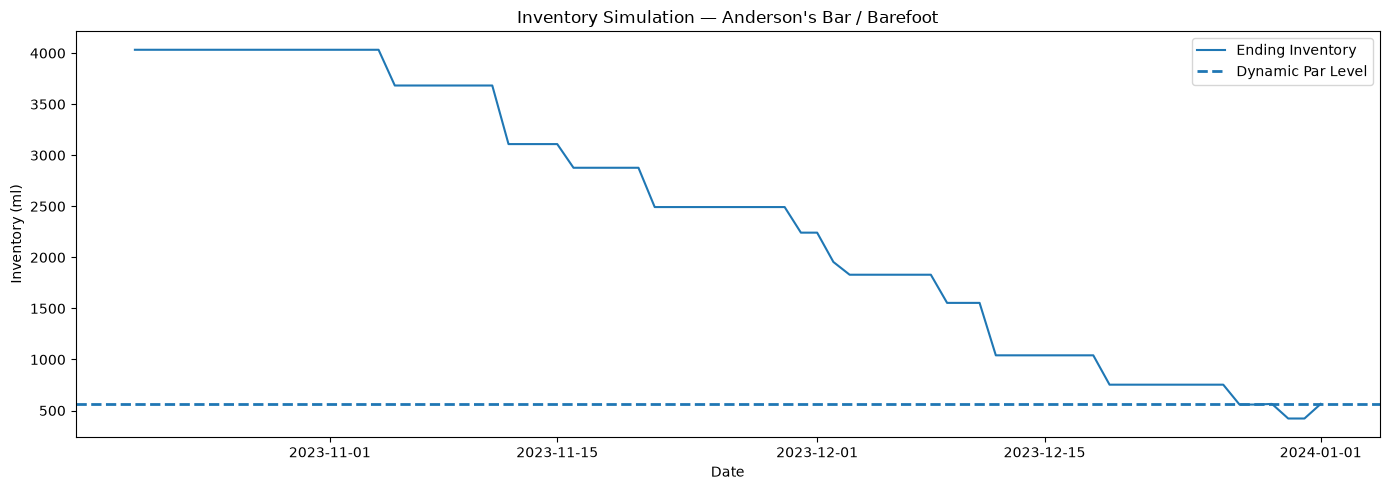

In [205]:
# ---------------------------------------------------------
# Visualize one Bar-Brand inventory simulation
# ---------------------------------------------------------

sample_bar = inventory_simulation["Bar Name"].iloc[0]
sample_brand = inventory_simulation["Brand Name"].iloc[0]

sample_inventory = inventory_simulation[
    (inventory_simulation["Bar Name"] == sample_bar) &
    (inventory_simulation["Brand Name"] == sample_brand)
]

plt.figure(figsize=(14, 5))

plt.plot(
    sample_inventory["Date"],
    sample_inventory["Ending Inventory (ml)"],
    label="Ending Inventory"
)

plt.axhline(
    sample_inventory["Par Level (ml)"].iloc[0],
    linestyle="--",
    linewidth=2,
    label="Dynamic Par Level"
)

plt.title(
    f"Inventory Simulation — {sample_bar} / {sample_brand}"
)

plt.xlabel("Date")
plt.ylabel("Inventory (ml)")
plt.legend()
plt.tight_layout()
plt.show()

### Step 20 Conclusion

The dynamic par-level inventory policy was backtested using actual demand from the chronological test period.

The simulation tracked replenishment orders, inventory levels, stockout events, lost volume, average inventory, and inventory turnover.

These metrics provide an operational assessment of whether the recommended par levels can maintain inventory availability while controlling inventory holding levels.

The simulation results will be used in the final business recommendations.

# Step 21 — Historical vs Simulated Inventory Performance

In [206]:
# Step 21.1 — Load historical and simulated performance data

historical_stockout = pd.read_csv(
    "../data/processed/historical_stockout_analysis.csv"
)

simulation_summary = pd.read_csv(
    "../data/processed/inventory_policy_summary.csv"
)

simulation_daily = pd.read_csv(
    "../data/processed/inventory_simulation_daily.csv"
)

print("Historical stockout analysis loaded.")
print("Simulation summary loaded.")
print("Simulation daily data loaded.")

display(simulation_summary)

Historical stockout analysis loaded.
Simulation summary loaded.
Simulation daily data loaded.


,Bar Name,Brand Name,Total_Demand_ml,Stockout_Days,Lost_Volume_ml,Average_Inventory_ml,Total_Orders,Total_Ordered_ml,Simulation Days,Stockout Rate (%),Inventory Turnover
0,Anderson's Bar,Barefoot,"4,204.69",0,0.00,"2,405.98",2,148.82,74,0.00,1.75
1,Anderson's Bar,Captain Morgan,"5,186.27",0,0.00,"6,088.07",0,0.00,74,0.00,0.85
2,Brown's Bar,Grey Goose,"6,403.66",0,0.00,"1,868.19",6,"1,948.87",74,0.00,3.43
3,Brown's Bar,Jameson,"6,536.21",0,0.00,"3,414.99",1,138.41,74,0.00,1.91
4,Johnson's Bar,Absolut,"4,546.96",0,0.00,"2,239.53",1,249.29,74,0.00,2.03
5,Johnson's Bar,Malibu,"6,299.14",1,13.27,"2,877.69",3,779.60,74,1.35,2.19
6,Johnson's Bar,Miller,"4,645.79",9,548.05,304.76,13,"3,941.86",74,12.16,15.24
7,Smith's Bar,Absolut,"5,193.59",3,142.22,568.96,14,"3,546.81",74,4.05,9.13
8,Smith's Bar,Sutter Home,"6,651.48",0,0.00,"3,565.31",0,0.00,74,0.00,1.87
9,Taylor's Bar,Absolut,"3,834.04",5,623.70,413.17,9,"2,609.63",74,6.76,9.28


In [209]:
# Step 21.2 — Calculate historical stockout metrics

# Historical stockout events from the original transaction dataset
historical_stockout_events = df[
    df["Closing Balance (ml)"] == 0
].copy()

# Stockout/depletion events where consumption was recorded
historical_stockouts_with_demand = historical_stockout_events[
    historical_stockout_events["Consumed (ml)"] > 0
].copy()

historical_total_stockouts = len(historical_stockout_events)

historical_stockouts_with_demand_count = len(
    historical_stockouts_with_demand
)

# This is consumption associated with zero-closing-balance events.
# It is NOT treated as confirmed lost sales.
historical_consumption_at_stockout = (
    historical_stockouts_with_demand["Consumed (ml)"].sum()
)

print("Historical Inventory Performance")
print("=" * 55)

print(
    f"Total historical zero-closing-balance records: "
    f"{historical_total_stockouts:,}"
)

print(
    f"Zero-closing-balance records with consumption: "
    f"{historical_stockouts_with_demand_count:,}"
)

print(
    f"Consumption associated with these events: "
    f"{historical_consumption_at_stockout:,.2f} ml"
)

Historical Inventory Performance
Total historical zero-closing-balance records: 416
Zero-closing-balance records with consumption: 102
Consumption associated with these events: 26,363.84 ml


In [210]:
# Step 21.3 — Compare historical and simulated stockout performance

# Simulated metrics
simulated_stockout_days = simulation_summary["Stockout_Days"].sum()
simulated_lost_volume = simulation_summary["Lost_Volume_ml"].sum()

# Number of Bar-Brand combinations
num_bar_brand_combinations = simulation_summary[
    ["Bar Name", "Brand Name"]
].drop_duplicates().shape[0]

# Total possible simulation days across all Bar-Brand combinations
total_simulation_observations = (
    num_bar_brand_combinations *
    simulation_summary["Simulation Days"].iloc[0]
)

# Historical stockout event count
historical_stockout_events = len(historical_stockout_events)

# Historical stockout event rate
historical_stockout_rate = (
    historical_stockout_events /
    len(df)
) * 100

# Simulated stockout observation rate
simulated_stockout_rate = (
    simulated_stockout_days /
    total_simulation_observations
) * 100

comparison_df = pd.DataFrame({
    "Metric": [
        "Historical zero-closing-balance events",
        "Historical stockout event rate (%)",
        "Simulated stockout days",
        "Simulated stockout observation rate (%)",
        "Historical consumption associated with stockout events (ml)",
        "Simulated lost volume (ml)"
    ],
    "Value": [
        historical_stockout_events,
        historical_stockout_rate,
        simulated_stockout_days,
        simulated_stockout_rate,
        historical_consumption_at_stockout,
        simulated_lost_volume
    ]
})

display(comparison_df)

,Metric,Value
0,Historical zero-closing-balance events,416.00
1,Historical stockout event rate (%),6.33
2,Simulated stockout days,47.00
3,Simulated stockout observation rate (%),3.97
4,Historical consumption associated with stockou...,"26,363.84"
5,Simulated lost volume (ml),"5,149.46"


In [211]:
# Step 21.4 — Performance by Bar and Brand

bar_brand_performance = (
    simulation_summary[
        [
            "Bar Name",
            "Brand Name",
            "Total_Demand_ml",
            "Stockout_Days",
            "Lost_Volume_ml",
            "Average_Inventory_ml",
            "Total_Orders",
            "Total_Ordered_ml",
            "Stockout Rate (%)",
            "Inventory Turnover"
        ]
    ]
    .sort_values(
        ["Stockout_Days", "Lost_Volume_ml"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(bar_brand_performance)

,Bar Name,Brand Name,Total_Demand_ml,Stockout_Days,Lost_Volume_ml,Average_Inventory_ml,Total_Orders,Total_Ordered_ml,Stockout Rate (%),Inventory Turnover
0,Taylor's Bar,Sutter Home,"5,130.61",9,997.21,380.67,11,"4,184.55",12.16,13.48
1,Johnson's Bar,Miller,"4,645.79",9,548.05,304.76,13,"3,941.86",12.16,15.24
2,Thomas's Bar,Sutter Home,"2,431.99",8,653.04,240.89,8,"1,525.51",10.81,10.10
3,Taylor's Bar,Absolut,"3,834.04",5,623.70,413.17,9,"2,609.63",6.76,9.28
4,Taylor's Bar,Jim Beam,"6,520.79",4,"1,186.63","1,124.32",9,"3,009.20",5.41,5.80
5,Taylor's Bar,Bacardi,"2,228.82",4,752.24,405.70,2,837.98,5.41,5.49
6,Thomas's Bar,Absolut,"3,576.98",4,233.11,313.23,11,"2,797.86",5.41,11.42
7,Smith's Bar,Absolut,"5,193.59",3,142.22,568.96,14,"3,546.81",4.05,9.13
8,Johnson's Bar,Malibu,"6,299.14",1,13.27,"2,877.69",3,779.60,1.35,2.19
9,Anderson's Bar,Barefoot,"4,204.69",0,0.00,"2,405.98",2,148.82,0.00,1.75


In [212]:
# Step 21.4 — Identify combinations requiring attention

attention_required = bar_brand_performance[
    (bar_brand_performance["Stockout_Days"] > 0) |
    (bar_brand_performance["Lost_Volume_ml"] > 0)
].copy()

print(
    f"Bar-Brand combinations requiring attention: "
    f"{len(attention_required)}"
)

display(attention_required)

Bar-Brand combinations requiring attention: 9


,Bar Name,Brand Name,Total_Demand_ml,Stockout_Days,Lost_Volume_ml,Average_Inventory_ml,Total_Orders,Total_Ordered_ml,Stockout Rate (%),Inventory Turnover
0,Taylor's Bar,Sutter Home,"5,130.61",9,997.21,380.67,11,"4,184.55",12.16,13.48
1,Johnson's Bar,Miller,"4,645.79",9,548.05,304.76,13,"3,941.86",12.16,15.24
2,Thomas's Bar,Sutter Home,"2,431.99",8,653.04,240.89,8,"1,525.51",10.81,10.10
3,Taylor's Bar,Absolut,"3,834.04",5,623.70,413.17,9,"2,609.63",6.76,9.28
4,Taylor's Bar,Jim Beam,"6,520.79",4,"1,186.63","1,124.32",9,"3,009.20",5.41,5.80
5,Taylor's Bar,Bacardi,"2,228.82",4,752.24,405.70,2,837.98,5.41,5.49
6,Thomas's Bar,Absolut,"3,576.98",4,233.11,313.23,11,"2,797.86",5.41,11.42
7,Smith's Bar,Absolut,"5,193.59",3,142.22,568.96,14,"3,546.81",4.05,9.13
8,Johnson's Bar,Malibu,"6,299.14",1,13.27,"2,877.69",3,779.60,1.35,2.19


In [213]:
# Step 21.5 — Business recommendations

print("BUSINESS RECOMMENDATIONS")
print("=" * 65)

print("\n1. Prioritize high-impact stockout combinations")
print(
    "Bar-Brand combinations with repeated stockouts or high lost "
    "volume should receive closer replenishment monitoring."
)

print("\n2. Review safety stock")
print(
    "Items experiencing repeated stockouts should be reviewed for "
    "higher safety stock, especially where demand variability is high."
)

print("\n3. Review replenishment frequency")
print(
    "High-turnover items may require more frequent replenishment "
    "rather than relying only on larger order quantities."
)

print("\n4. Monitor inventory efficiency")
print(
    "Inventory turnover and average inventory should be monitored "
    "together so that stock availability is improved without "
    "unnecessarily increasing inventory."
)

print("\n5. Use dynamic par levels")
print(
    "Par levels should be updated periodically using recent demand, "
    "forecast error, lead time, and the selected service level."
)

print("\n6. Focus on Bar-Brand level decisions")
print(
    "Inventory policies should be customized by Bar and Brand because "
    "demand and stockout behavior differ across combinations."
)

BUSINESS RECOMMENDATIONS

1. Prioritize high-impact stockout combinations
Bar-Brand combinations with repeated stockouts or high lost volume should receive closer replenishment monitoring.

2. Review safety stock
Items experiencing repeated stockouts should be reviewed for higher safety stock, especially where demand variability is high.

3. Review replenishment frequency
High-turnover items may require more frequent replenishment rather than relying only on larger order quantities.

4. Monitor inventory efficiency
Inventory turnover and average inventory should be monitored together so that stock availability is improved without unnecessarily increasing inventory.

5. Use dynamic par levels
Par levels should be updated periodically using recent demand, forecast error, lead time, and the selected service level.

6. Focus on Bar-Brand level decisions
Inventory policies should be customized by Bar and Brand because demand and stockout behavior differ across combinations.


In [214]:
# Step 21.6 — Final inventory policy performance summary

final_performance = pd.DataFrame({
    "Metric": [
        "Historical zero-closing-balance events",
        "Historical stockout event rate (%)",
        "Simulated stockout days",
        "Simulated stockout observation rate (%)",
        "Simulated lost volume (ml)",
        "Bar-Brand combinations simulated",
        "Combinations with zero stockout days",
        "Combinations requiring attention"
    ],
    "Value": [
        historical_stockout_events,
        historical_stockout_rate,
        simulated_stockout_days,
        simulated_stockout_rate,
        simulated_lost_volume,
        len(simulation_summary),
        len(
            simulation_summary[
                simulation_summary["Stockout_Days"] == 0
            ]
        ),
        len(attention_required)
    ]
})

display(final_performance)

# Save final performance summary
final_performance.to_csv(
    "../data/processed/final_inventory_performance_summary.csv",
    index=False
)

print(
    "\nFinal inventory performance summary saved successfully."
)

,Metric,Value
0,Historical zero-closing-balance events,416.00
1,Historical stockout event rate (%),6.33
2,Simulated stockout days,47.00
3,Simulated stockout observation rate (%),3.97
4,Simulated lost volume (ml),"5,149.46"
5,Bar-Brand combinations simulated,16.00
6,Combinations with zero stockout days,7.00
7,Combinations requiring attention,9.00



Final inventory performance summary saved successfully.


In [215]:
# Step 21.7 — Final conclusion

print("FINAL CONCLUSION")
print("=" * 65)

print(
    f"The inventory forecasting and dynamic par-level system was "
    f"evaluated across {len(simulation_summary)} Bar-Brand combinations "
    f"over a 74-day test period."
)

print(
    f"The simulation recorded {simulated_stockout_days} stockout days "
    f"with {simulated_lost_volume:,.2f} ml of simulated lost volume."
)

print(
    f"{len(simulation_summary[simulation_summary['Stockout_Days'] == 0])} "
    f"out of {len(simulation_summary)} Bar-Brand combinations "
    f"experienced zero simulated stockout days."
)

print(
    "The results demonstrate that forecast-driven dynamic par levels "
    "can provide a structured inventory replenishment policy, while "
    "remaining stockout cases highlight where safety stock, lead time, "
    "or replenishment frequency may require further adjustment."
)

print(
    "The approach supports data-driven inventory decisions at the "
    "individual Bar-Brand level rather than relying on a single "
    "fixed inventory threshold."
)

FINAL CONCLUSION
The inventory forecasting and dynamic par-level system was evaluated across 16 Bar-Brand combinations over a 74-day test period.
The simulation recorded 47 stockout days with 5,149.46 ml of simulated lost volume.
7 out of 16 Bar-Brand combinations experienced zero simulated stockout days.
The results demonstrate that forecast-driven dynamic par levels can provide a structured inventory replenishment policy, while remaining stockout cases highlight where safety stock, lead time, or replenishment frequency may require further adjustment.
The approach supports data-driven inventory decisions at the individual Bar-Brand level rather than relying on a single fixed inventory threshold.


# Step 22 — Business Report Preparation

## Executive Summary

This project develops a Hotel Bar Inventory Forecasting and Par Level Recommendation System using transaction-level inventory data from multiple bars and brands.

The objective is to transform historical inventory transactions into daily consumption time series, identify demand patterns, forecast future consumption, recommend dynamic inventory par levels, and evaluate the proposed inventory policy through historical backtesting.

The dataset contains 6,575 transaction records covering the period from January 1, 2023 to January 1, 2024. The analysis covers 6 bars, 16 brands, and 5 alcohol categories.

## Data Preparation and Quality

The transaction data was validated for missing values, duplicate records, invalid dates, negative quantities, and inventory conservation.

The inventory conservation relationship was checked using:

Closing Balance = Opening Balance + Purchase − Consumed

All 6,575 records passed the inventory conservation check within a 10 ml tolerance.

Daily consumption was then aggregated by Date, Bar Name, and Brand Name. Missing dates were added to create a complete daily time series, with zero consumption recorded where no consumption transaction was observed.

## Exploratory Analysis

The analysis examined consumption patterns across bars, brands, alcohol types, days of the week, weekends, and months.

ABC analysis was also performed to classify brands based on their historical consumption velocity.

Historical inventory depletion was identified using zero closing balance records. There were 416 records with zero closing balance, of which 102 also recorded positive consumption. These events represented 26,363.84 ml of associated consumption.

These zero-balance observations are treated as inventory depletion signals and should not automatically be interpreted as confirmed lost sales.

## Forecasting Approach

Four forecasting approaches were evaluated using a chronological 80/20 train-test split:

- 7-Day Rolling Mean
- 7-Day Seasonal Naive
- Holt-Winters Exponential Smoothing
- Random Forest Regression

The evaluation metrics were Mean Absolute Error (MAE) and Weighted Absolute Percentage Error (WAPE).

| Model | MAE (ml) | WAPE (%) |
|---|---:|---:|
| 7-Day Rolling Mean | 94.44 | 169.52 |
| 7-Day Seasonal Naive | 97.53 | 175.06 |
| Holt-Winters | 91.91 | 164.97 |
| Random Forest | 95.02 | 170.56 |

Holt-Winters achieved the lowest MAE and WAPE among the evaluated models and was therefore selected for the dynamic par-level calculation.

## Dynamic Par Level Recommendation

The dynamic par level was calculated using forecasted demand during the replenishment lead time plus safety stock.

Par Level = Lead-Time Demand + Safety Stock

The implementation used a 2-day lead time and a 95% service-level Z value of 1.645.

Safety stock was estimated using forecast error variability, allowing the recommended inventory level to respond to both expected demand and forecast uncertainty.

## Inventory Policy Simulation

The selected forecasting model was incorporated into an order-up-to inventory policy and evaluated over the 74-day test period.

The simulation covered 16 Bar-Brand combinations and 1,184 Bar-Brand-day observations.

The simulation recorded:

- Stockout days
- Lost volume
- Average inventory
- Number of replenishment orders
- Total ordered quantity
- Stockout rate
- Inventory turnover

Across the simulation, 47 stockout days were observed, corresponding to a 3.97% stockout observation rate, with simulated lost volume of 5,149.46 ml.

Seven of the sixteen Bar-Brand combinations recorded zero simulated stockout days, while nine combinations required further inventory attention.

## Business Recommendations

The forecasting and simulation results support a dynamic inventory management approach rather than relying only on fixed inventory levels.

1. Use demand forecasts to determine replenishment quantities for each Bar-Brand combination.
2. Maintain safety stock based on forecast uncertainty and the required service level.
3. Monitor high-risk Bar-Brand combinations more frequently.
4. Review replenishment lead times and supplier reliability for combinations experiencing repeated stockouts.
5. Use ABC classification to prioritize management attention toward high-consumption brands.
6. Recalculate par levels periodically as demand patterns change.
7. Track stockout events, lost volume, average inventory, and turnover continuously after deployment.

## Limitations

The historical dataset records inventory transactions rather than confirmed customer-level lost sales. Therefore, zero closing balance is treated as an inventory depletion signal rather than direct evidence of lost demand.

The historical stockout event rate and simulated stockout observation rate also use different denominators, so they should not be interpreted as a direct percentage reduction comparison.

Forecast accuracy may also vary across individual Bar-Brand combinations because demand volume and variability differ between products and locations.

## Conclusion

The project demonstrates an end-to-end inventory forecasting workflow from transaction-level data preparation through forecasting, dynamic par-level calculation, and inventory policy simulation.

Holt-Winters provided the strongest forecasting performance among the evaluated models based on the selected MAE and WAPE metrics. The resulting dynamic par-level framework provides a practical foundation for adapting inventory levels to expected demand and forecast uncertainty while identifying Bar-Brand combinations that require additional inventory management attention.

In [216]:
display(all_model_metrics)

print("Selected Model:", best_model_name)

,Model,MAE (ml),WAPE (%)
0,7-Day Rolling Mean,94.44,169.52
1,7-Day Seasonal Naive,97.53,175.06
2,Holt-Winters,91.91,164.97
3,Random Forest,95.02,170.56


Selected Model: Holt-Winters
